# IEEE-CIS Fraud Detection — Phase 3 & 3.5: Classification, Tuning & Threshold Optimization

**Inputs from Phase 1/2/2.5 notebook**:
- `augmented_train_qt.csv` — train split + best-generator synthetic fraud at the searched ratio
- `val_qt.csv` / `test_qt.csv` — untouched validation / held-out test splits
- `phase1_baseline_results.csv` — Phase 1 reference metrics
- `phase2_pipeline_meta.pkl` — best generator name, best ratio, feature column lists
- `experiment_log.csv` — running experiment log (this notebook appends to it)

### What changed vs. the previous version
| Area | v2 | v3 (this notebook) |
|---|---|---|
| Classifier objective | Optuna maximizes plain F1 | Optuna maximizes a **weighted business objective**: `0.5·Recall + 0.3·F1 + 0.2·ROC-AUC` |
| Model family | XGBoost + LightGBM + RF | adds **CatBoost**, **Balanced Random Forest**, **Easy Ensemble** |
| Calibration | none | **Platt scaling / Isotonic regression** applied before threshold optimization |
| Threshold search | single F1-optimal point | **Phase 3.5**: full 0.05→0.95 sweep, optimized for business cost / F2 / recall subject to precision ≥ 0.85 |
| Final model | single best model | **soft-voting ensemble** (weights tuned automatically) vs. single-best comparison |
| Experiment tracking | none | every model/config logged to `experiment_log.csv` (config, timing, val/test metrics) |

Phase 4 (SHAP explainability + full ablation-study suite) lives in the companion notebook.


## 1. Imports & Configuration

In [1]:

import subprocess, sys, warnings, time, os, re, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
from scipy.optimize import minimize

# ── Install optional packages ─────────────────────────────────────────────────
for pkg, imp in [('optuna', 'optuna'), ('lightgbm', 'lightgbm'), ('xgboost', 'xgboost'),
                  ('catboost', 'catboost'), ('imbalanced-learn', 'imblearn')]:
    try:
        __import__(imp)
        print(f'[OK] {pkg}')
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
        print(f'[INSTALLED] {pkg}')

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import xgboost as xgb
import lightgbm as lgb
try:
    from catboost import CatBoostClassifier
    CATBOOST_OK = True
except ImportError:
    CATBOOST_OK = False
    print('[WARN] CatBoost not available')

try:
    from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
    IMBLEARN_ENSEMBLE_OK = True
except ImportError:
    IMBLEARN_ENSEMBLE_OK = False
    print('[WARN] imbalanced-learn ensemble classifiers not available')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix, precision_recall_curve, f1_score, recall_score,
    roc_curve, precision_score, accuracy_score, fbeta_score, brier_score_loss
)

warnings.filterwarnings('ignore')
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('ggplot')
sns.set_palette('husl')
sns.set_context('notebook', font_scale=1.1)

SEED = 42
np.random.seed(SEED)

print('\n=== Phase 3: Fraud Classification & Tuning ===')
print(f'NumPy {np.__version__} | Pandas {pd.__version__}')
print(f'XGBoost {xgb.__version__} | LightGBM {lgb.__version__}'
      f'{" | CatBoost available" if CATBOOST_OK else ""}')
print('Environment ready ✓')

# ── Experiment tracking (appends to the log started in the Phase 1/2 notebook) ──
EXPERIMENT_LOG_PATH = 'experiment_log.csv'
_experiment_records = []
if os.path.exists(EXPERIMENT_LOG_PATH):
    try:
        _experiment_records = pd.read_csv(EXPERIMENT_LOG_PATH).to_dict(orient='records')
        print(f'Loaded {len(_experiment_records)} existing experiment records')
    except Exception:
        _experiment_records = []

def log_experiment(name, phase, config=None, timing_s=None, memory_mb=None,
                    quality_metrics=None, val_metrics=None, test_metrics=None, notes=''):
    rec = {
        'timestamp': pd.Timestamp.now().isoformat(), 'phase': phase, 'experiment': name,
        'seed': SEED, 'config': json.dumps(config or {}, default=str),
        'timing_s': round(timing_s, 2) if timing_s is not None else None,
        'memory_mb': round(memory_mb, 1) if memory_mb is not None else None,
        'quality_metrics': json.dumps(quality_metrics or {}, default=str),
        'val_metrics': json.dumps(val_metrics or {}, default=str),
        'test_metrics': json.dumps(test_metrics or {}, default=str),
        'notes': notes,
    }
    _experiment_records.append(rec)
    pd.DataFrame(_experiment_records).to_csv(EXPERIMENT_LOG_PATH, index=False)
    return rec

print('Experiment tracking ready (appending to experiment_log.csv) ✓')


[OK] optuna
[OK] lightgbm
[OK] xgboost
[OK] catboost
[OK] imbalanced-learn

=== Phase 3: Fraud Classification & Tuning ===
NumPy 2.0.2 | Pandas 2.3.3
XGBoost 3.2.0 | LightGBM 4.6.0 | CatBoost available
Environment ready ✓
Experiment tracking ready (appending to experiment_log.csv) ✓


## 2. Load Phase 2 / 2.5 Outputs

In [4]:

print('Loading Phase 2/2.5 data splits and metadata…')

aug_df   = pd.read_csv('/kaggle/input/datasets/ahmedzc/phase-1-2-results/augmented_train_qt.csv')
val_df   = pd.read_csv('/kaggle/input/datasets/ahmedzc/phase-1-2-results/test_qt.csv')
test_df  = pd.read_csv('/kaggle/input/datasets/ahmedzc/phase-1-2-results/val_qt.csv')

try:
    pipeline_meta = joblib.load('phase2_pipeline_meta.pkl')
    print(f'Best generator (from Phase 2.5): {pipeline_meta.get("best_generator")}')
    print(f'Best augmentation ratio        : {pipeline_meta.get("best_augmentation_ratio"):.0%}')
except FileNotFoundError:
    pipeline_meta = {}
    print('[WARN] phase2_pipeline_meta.pkl not found — proceeding without it')

FEATURE_COLS = [c for c in aug_df.columns if c != 'isFraud']

X_train_aug = aug_df[FEATURE_COLS].values
y_train_aug = aug_df['isFraud'].values.astype(int)

X_val  = val_df[FEATURE_COLS].values
y_val  = val_df['isFraud'].values.astype(int)

X_test = test_df[FEATURE_COLS].values
y_test = test_df['isFraud'].values.astype(int)

print(f'Augmented train : {X_train_aug.shape}  fraud: {y_train_aug.mean()*100:.2f}%  ({y_train_aug.sum():,} fraud)')
print(f'Validation      : {X_val.shape}         fraud: {y_val.mean()*100:.2f}%  ({y_val.sum():,} fraud)')
print(f'Test            : {X_test.shape}         fraud: {y_test.mean()*100:.2f}%  ({y_test.sum():,} fraud)')
print(f'Feature count   : {len(FEATURE_COLS)}')
print(f'\nClass imbalance in aug train: {(1-y_train_aug.mean())/y_train_aug.mean():.1f}:1')


Loading Phase 2/2.5 data splits and metadata…
[WARN] phase2_pipeline_meta.pkl not found — proceeding without it
Augmented train : (427842, 414)  fraud: 6.76%  (28,928 fraud)
Validation      : (88581, 414)         fraud: 3.50%  (3,099 fraud)
Test            : (88581, 414)         fraud: 3.50%  (3,100 fraud)
Feature count   : 414

Class imbalance in aug train: 13.8:1


## 3. Reconstruct Real-Only Train Set (for Baseline Comparison)

In [5]:

# The augmented set has synthetic rows appended at the end (isFraud==1).
# Estimate the original real fraud count from val/test (same stratified split ratio):
# val=15%, test=15% of total → train=70%.
n_val_fraud  = int(y_val.sum())
n_test_fraud = int(y_test.sum())
total_fraud_est = int((n_val_fraud + n_test_fraud) / 0.30)
n_real_train_fraud_est = int(total_fraud_est * 0.70)

print(f'Estimated real fraud in train: ~{n_real_train_fraud_est:,}')
print(f'Actual fraud rows in aug train: {y_train_aug.sum():,}')
n_synthetic_est = max(0, int(y_train_aug.sum()) - n_real_train_fraud_est)
print(f'Estimated synthetic rows added: ~{n_synthetic_est:,}')

fraud_idx = np.where(y_train_aug == 1)[0]
legit_idx = np.where(y_train_aug == 0)[0]
real_fraud_idx = fraud_idx[:n_real_train_fraud_est]
real_idx = np.sort(np.concatenate([legit_idx, real_fraud_idx]))

X_train_real = X_train_aug[real_idx]
y_train_real = y_train_aug[real_idx]
print(f'\nReal-only train: {X_train_real.shape}  fraud: {y_train_real.mean()*100:.2f}%')
print(f'Augmented train: {X_train_aug.shape}  fraud: {y_train_aug.mean()*100:.2f}%')


Estimated real fraud in train: ~14,464
Actual fraud rows in aug train: 28,928
Estimated synthetic rows added: ~14,464

Real-only train: (413378, 414)  fraud: 3.50%
Augmented train: (427842, 414)  fraud: 6.76%


## 4. Evaluation Helpers

In [8]:

def find_optimal_threshold(y_true, y_prob, metric='f1'):
    prec, rec, thresholds = precision_recall_curve(y_true, y_prob)
    f1s = 2 * prec * rec / (prec + rec + 1e-9)
    best_idx = np.argmax(f1s[:-1])
    return thresholds[best_idx], f1s[best_idx]

def full_eval(name, y_true, y_prob, threshold=None, verbose=True):
    if threshold is None:
        threshold, _ = find_optimal_threshold(y_true, y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    roc  = roc_auc_score(y_true, y_prob)
    ap   = average_precision_score(y_true, y_prob)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    fpr  = confusion_matrix(y_true, y_pred)[0, 1] / max((y_true == 0).sum(), 1)
    result = {
        'Model': name, 'ROC_AUC': round(roc, 4), 'Avg_Precision': round(ap, 4),
        'Recall': round(rec, 4), 'Precision': round(prec, 4), 'F1': round(f1, 4),
        'FPR': round(fpr, 4), 'Threshold': round(threshold, 4),
        'y_prob': y_prob, 'y_pred': y_pred,
    }
    if verbose:
        print(f'{name:35s} | ROC-AUC: {roc:.4f}  AP: {ap:.4f}  '
              f'Recall: {rec:.4f}  Prec: {prec:.4f}  F1: {f1:.4f}  '
              f'FPR: {fpr:.4f}  thr={threshold:.3f}')
    return result

def scale_pos_weight_calc(y):
    return max(1, (y == 0).sum() / max((y == 1).sum(), 1))

def business_objective(recall, f1, roc_auc, w_recall=0.5, w_f1=0.3, w_auc=0.2):
    # Weighted objective used by Optuna: 0.5*Recall + 0.3*F1 + 0.2*ROC-AUC (per plan).
    return w_recall * recall + w_f1 * f1 + w_auc * roc_auc

results_registry = {}   # name → result dict

print('Helpers defined ✓')
print('Optuna objective: 0.5·Recall + 0.3·F1 + 0.2·ROC-AUC')


Helpers defined ✓
Optuna objective: 0.5·Recall + 0.3·F1 + 0.2·ROC-AUC


## 5. Baseline Models — Real-Only Training

Train classifiers on the **original (non-augmented) training data** to establish a fair
baseline. In addition to XGBoost / LightGBM / Random Forest, this version adds **CatBoost**
(especially good for categorical variables) and, when available, **Balanced Random Forest**
and **Easy Ensemble** (both from `imbalanced-learn`, generally strong for class imbalance).


In [9]:

print('=' * 80)
print('BASELINE MODELS — Trained on REAL DATA ONLY (no synthetic augmentation)')
print('=' * 80)
print()

spw_real = scale_pos_weight_calc(y_train_real)
t_base_all = time.time()

# ── 1. XGBoost Baseline ───────────────────────────────────────────────────────
print('[1/5] XGBoost (baseline, real-only) …')
t0 = time.time()
xgb_base = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    min_child_weight=3, subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw_real, tree_method='hist',
    random_state=SEED, n_jobs=-1, verbosity=0,
    eval_metric='logloss', early_stopping_rounds=30
)
xgb_base.fit(X_train_real, y_train_real, eval_set=[(X_val, y_val)], verbose=False)
prob = xgb_base.predict_proba(X_val)[:, 1]
r = full_eval('XGBoost (real-only)', y_val, prob)
results_registry['XGBoost_baseline'] = r
print(f'  Training time: {time.time()-t0:.1f}s  |  Best iteration: {xgb_base.best_iteration}')
log_experiment('XGBoost_baseline', phase='phase3', timing_s=time.time()-t0, val_metrics=r,
               config={'data': 'real_only'})

# ── 2. LightGBM Baseline ──────────────────────────────────────────────────────
print()
print('[2/5] LightGBM (baseline, real-only) …')
t0 = time.time()
lgb_base = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    num_leaves=63, min_child_samples=20,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw_real,
    random_state=SEED, n_jobs=-1, verbosity=-1
)
lgb_base.fit(X_train_real, y_train_real, eval_set=[(X_val, y_val)],
             callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])
prob = lgb_base.predict_proba(X_val)[:, 1]
r = full_eval('LightGBM (real-only)', y_val, prob)
results_registry['LightGBM_baseline'] = r
print(f'  Training time: {time.time()-t0:.1f}s')
log_experiment('LightGBM_baseline', phase='phase3', timing_s=time.time()-t0, val_metrics=r,
               config={'data': 'real_only'})

# ── 3. Random Forest Baseline ─────────────────────────────────────────────────
print()
print('[3/5] Random Forest (baseline, real-only) …')
t0 = time.time()
rf_base = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=5,
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
rf_base.fit(X_train_real, y_train_real)
prob = rf_base.predict_proba(X_val)[:, 1]
r = full_eval('Random Forest (real-only)', y_val, prob)
results_registry['RF_baseline'] = r
print(f'  Training time: {time.time()-t0:.1f}s')
log_experiment('RF_baseline', phase='phase3', timing_s=time.time()-t0, val_metrics=r,
               config={'data': 'real_only'})

# ── 4. CatBoost Baseline ──────────────────────────────────────────────────────
if CATBOOST_OK:
    print()
    print('[4/5] CatBoost (baseline, real-only) …')
    t0 = time.time()
    cat_base = CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=6,
        l2_leaf_reg=3.0, scale_pos_weight=spw_real,
        random_seed=SEED, verbose=False, early_stopping_rounds=30,
        task_type='GPU' if os.environ.get('CUDA_VISIBLE_DEVICES') else 'CPU',
    )
    try:
        cat_base.fit(X_train_real, y_train_real, eval_set=(X_val, y_val), verbose=False)
    except Exception:
        cat_base = CatBoostClassifier(
            iterations=500, learning_rate=0.05, depth=6, l2_leaf_reg=3.0,
            scale_pos_weight=spw_real, random_seed=SEED, verbose=False,
            early_stopping_rounds=30, task_type='CPU')
        cat_base.fit(X_train_real, y_train_real, eval_set=(X_val, y_val), verbose=False)
    prob = cat_base.predict_proba(X_val)[:, 1]
    r = full_eval('CatBoost (real-only)', y_val, prob)
    results_registry['CatBoost_baseline'] = r
    print(f'  Training time: {time.time()-t0:.1f}s')
    log_experiment('CatBoost_baseline', phase='phase3', timing_s=time.time()-t0, val_metrics=r,
                   config={'data': 'real_only'})
else:
    cat_base = None
    print('[SKIP] CatBoost not available')

# ── 5. Balanced Random Forest / Easy Ensemble ─────────────────────────────────
if IMBLEARN_ENSEMBLE_OK:
    print()
    print('[5/5] Balanced Random Forest + Easy Ensemble (baseline, real-only) …')
    t0 = time.time()
    brf_base = BalancedRandomForestClassifier(
        n_estimators=300, max_depth=12, sampling_strategy='auto',
        replacement=True, bootstrap=False, random_state=SEED, n_jobs=-1)
    brf_base.fit(X_train_real, y_train_real)
    prob = brf_base.predict_proba(X_val)[:, 1]
    r = full_eval('Balanced RF (real-only)', y_val, prob)
    results_registry['BalancedRF_baseline'] = r
    print(f'  BalancedRF training time: {time.time()-t0:.1f}s')
    log_experiment('BalancedRF_baseline', phase='phase3', timing_s=time.time()-t0, val_metrics=r,
                   config={'data': 'real_only'})

    t0 = time.time()
    eec_base = EasyEnsembleClassifier(n_estimators=20, random_state=SEED, n_jobs=-1)
    eec_base.fit(X_train_real, y_train_real)
    prob = eec_base.predict_proba(X_val)[:, 1]
    r = full_eval('Easy Ensemble (real-only)', y_val, prob)
    results_registry['EasyEnsemble_baseline'] = r
    print(f'  EasyEnsemble training time: {time.time()-t0:.1f}s')
    log_experiment('EasyEnsemble_baseline', phase='phase3', timing_s=time.time()-t0, val_metrics=r,
                   config={'data': 'real_only'})
else:
    brf_base = eec_base = None
    print('[SKIP] Balanced RF / Easy Ensemble not available')

print()
print(f'Baseline models complete ✓  (total time: {time.time()-t_base_all:.1f}s)')


BASELINE MODELS — Trained on REAL DATA ONLY (no synthetic augmentation)

[1/5] XGBoost (baseline, real-only) …
XGBoost (real-only)                 | ROC-AUC: 0.9504  AP: 0.7274  Recall: 0.6257  Prec: 0.7574  F1: 0.6853  FPR: 0.0073  thr=0.729
  Training time: 100.7s  |  Best iteration: 499

[2/5] LightGBM (baseline, real-only) …
LightGBM (real-only)                | ROC-AUC: 0.8856  AP: 0.4562  Recall: 0.4960  Prec: 0.4559  F1: 0.4751  FPR: 0.0215  thr=0.126
  Training time: 14.9s

[3/5] Random Forest (baseline, real-only) …
Random Forest (real-only)           | ROC-AUC: 0.9107  AP: 0.6014  Recall: 0.5328  Prec: 0.6500  F1: 0.5856  FPR: 0.0104  thr=0.559
  Training time: 330.2s

[4/5] CatBoost (baseline, real-only) …
CatBoost (real-only)                | ROC-AUC: 0.9423  AP: 0.6867  Recall: 0.5666  Prec: 0.7592  F1: 0.6489  FPR: 0.0065  thr=0.793
  Training time: 91.9s

[5/5] Balanced Random Forest + Easy Ensemble (baseline, real-only) …
Balanced RF (real-only)             | ROC-AUC: 0

## 6. Models Trained on Synthetically-Augmented Data

Same model family as Section 5, now trained on the Phase 2/2.5 augmented dataset
(real + best-generator synthetic fraud, at the automatically-searched ratio).


In [10]:

print('=' * 80)
print('AUGMENTED MODELS — Trained on REAL + SYNTHETIC DATA (Phase 2/2.5 output)')
print('=' * 80)
print()

spw_aug = scale_pos_weight_calc(y_train_aug)
t_aug_all = time.time()

# ── 1. XGBoost Augmented ──────────────────────────────────────────────────────
print('[1/5] XGBoost (augmented) …')
t0 = time.time()
xgb_aug = xgb.XGBClassifier(
    n_estimators=600, learning_rate=0.05, max_depth=6,
    min_child_weight=3, subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw_aug, tree_method='hist',
    random_state=SEED, n_jobs=-1, verbosity=0,
    eval_metric='logloss', early_stopping_rounds=30
)
xgb_aug.fit(X_train_aug, y_train_aug, eval_set=[(X_val, y_val)], verbose=False)
prob = xgb_aug.predict_proba(X_val)[:, 1]
r = full_eval('XGBoost (augmented)', y_val, prob)
results_registry['XGBoost_aug'] = r
print(f'  Training time: {time.time()-t0:.1f}s  |  Best iteration: {xgb_aug.best_iteration}')
log_experiment('XGBoost_aug', phase='phase3', timing_s=time.time()-t0, val_metrics=r,
               config={'data': 'augmented'})

# ── 2. LightGBM Augmented ─────────────────────────────────────────────────────
print()
print('[2/5] LightGBM (augmented) …')
t0 = time.time()
lgb_aug = lgb.LGBMClassifier(
    n_estimators=600, learning_rate=0.05, max_depth=6,
    num_leaves=63, min_child_samples=20,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw_aug,
    random_state=SEED, n_jobs=-1, verbosity=-1
)
lgb_aug.fit(X_train_aug, y_train_aug, eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])
prob = lgb_aug.predict_proba(X_val)[:, 1]
r = full_eval('LightGBM (augmented)', y_val, prob)
results_registry['LightGBM_aug'] = r
print(f'  Training time: {time.time()-t0:.1f}s')
log_experiment('LightGBM_aug', phase='phase3', timing_s=time.time()-t0, val_metrics=r,
               config={'data': 'augmented'})

# ── 3. Random Forest Augmented ────────────────────────────────────────────────
print()
print('[3/5] Random Forest (augmented) …')
t0 = time.time()
rf_aug = RandomForestClassifier(
    n_estimators=300, max_depth=14, min_samples_leaf=3,
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
rf_aug.fit(X_train_aug, y_train_aug)
prob = rf_aug.predict_proba(X_val)[:, 1]
r = full_eval('Random Forest (augmented)', y_val, prob)
results_registry['RF_aug'] = r
print(f'  Training time: {time.time()-t0:.1f}s')
log_experiment('RF_aug', phase='phase3', timing_s=time.time()-t0, val_metrics=r,
               config={'data': 'augmented'})

# ── 4. CatBoost Augmented ─────────────────────────────────────────────────────
if CATBOOST_OK:
    print()
    print('[4/5] CatBoost (augmented) …')
    t0 = time.time()
    cat_aug = CatBoostClassifier(
        iterations=600, learning_rate=0.05, depth=6, l2_leaf_reg=3.0,
        scale_pos_weight=spw_aug, random_seed=SEED, verbose=False,
        early_stopping_rounds=30, task_type='CPU')
    cat_aug.fit(X_train_aug, y_train_aug, eval_set=(X_val, y_val), verbose=False)
    prob = cat_aug.predict_proba(X_val)[:, 1]
    r = full_eval('CatBoost (augmented)', y_val, prob)
    results_registry['CatBoost_aug'] = r
    print(f'  Training time: {time.time()-t0:.1f}s')
    log_experiment('CatBoost_aug', phase='phase3', timing_s=time.time()-t0, val_metrics=r,
                   config={'data': 'augmented'})
else:
    cat_aug = None

# ── 5. Balanced Random Forest / Easy Ensemble ─────────────────────────────────
if IMBLEARN_ENSEMBLE_OK:
    print()
    print('[5/5] Balanced Random Forest + Easy Ensemble (augmented) …')
    t0 = time.time()
    brf_aug = BalancedRandomForestClassifier(
        n_estimators=300, max_depth=14, sampling_strategy='auto',
        replacement=True, bootstrap=False, random_state=SEED, n_jobs=-1)
    brf_aug.fit(X_train_aug, y_train_aug)
    prob = brf_aug.predict_proba(X_val)[:, 1]
    r = full_eval('Balanced RF (augmented)', y_val, prob)
    results_registry['BalancedRF_aug'] = r
    print(f'  BalancedRF training time: {time.time()-t0:.1f}s')
    log_experiment('BalancedRF_aug', phase='phase3', timing_s=time.time()-t0, val_metrics=r,
                   config={'data': 'augmented'})

    t0 = time.time()
    eec_aug = EasyEnsembleClassifier(n_estimators=20, random_state=SEED, n_jobs=-1)
    eec_aug.fit(X_train_aug, y_train_aug)
    prob = eec_aug.predict_proba(X_val)[:, 1]
    r = full_eval('Easy Ensemble (augmented)', y_val, prob)
    results_registry['EasyEnsemble_aug'] = r
    print(f'  EasyEnsemble training time: {time.time()-t0:.1f}s')
    log_experiment('EasyEnsemble_aug', phase='phase3', timing_s=time.time()-t0, val_metrics=r,
                   config={'data': 'augmented'})
else:
    brf_aug = eec_aug = None

print()
print(f'Augmented models complete ✓  (total time: {time.time()-t_aug_all:.1f}s)')


AUGMENTED MODELS — Trained on REAL + SYNTHETIC DATA (Phase 2/2.5 output)

[1/5] XGBoost (augmented) …
XGBoost (augmented)                 | ROC-AUC: 0.9600  AP: 0.7527  Recall: 0.6421  Prec: 0.7689  F1: 0.6998  FPR: 0.0070  thr=0.754
  Training time: 121.5s  |  Best iteration: 599

[2/5] LightGBM (augmented) …
LightGBM (augmented)                | ROC-AUC: 0.8801  AP: 0.4580  Recall: 0.4637  Prec: 0.4948  F1: 0.4788  FPR: 0.0172  thr=0.141
  Training time: 17.3s

[3/5] Random Forest (augmented) …
Random Forest (augmented)           | ROC-AUC: 0.9219  AP: 0.6370  Recall: 0.5637  Prec: 0.6784  F1: 0.6158  FPR: 0.0097  thr=0.564
  Training time: 267.1s

[4/5] CatBoost (augmented) …
CatBoost (augmented)                | ROC-AUC: 0.9491  AP: 0.7101  Recall: 0.5970  Prec: 0.7591  F1: 0.6684  FPR: 0.0069  thr=0.786
  Training time: 113.6s

[5/5] Balanced Random Forest + Easy Ensemble (augmented) …
Balanced RF (augmented)             | ROC-AUC: 0.9191  AP: 0.6279  Recall: 0.5795  Prec: 0.6219 

## 7. Baseline vs Augmented — Comparison Table & Visualisation


=== VALIDATION SET — ALL MODELS ===
                    Model  ROC_AUC  Avg_Precision  Recall  Precision     F1    FPR
      XGBoost (augmented)   0.9600         0.7527  0.6421     0.7689 0.6998 0.0070
      XGBoost (real-only)   0.9504         0.7274  0.6257     0.7574 0.6853 0.0073
     CatBoost (augmented)   0.9491         0.7101  0.5970     0.7591 0.6684 0.0069
     CatBoost (real-only)   0.9423         0.6867  0.5666     0.7592 0.6489 0.0065
Random Forest (augmented)   0.9219         0.6370  0.5637     0.6784 0.6158 0.0097
  Balanced RF (augmented)   0.9191         0.6279  0.5795     0.6219 0.6000 0.0128
Random Forest (real-only)   0.9107         0.6014  0.5328     0.6500 0.5856 0.0104
  Balanced RF (real-only)   0.9082         0.5894  0.5295     0.6237 0.5728 0.0116
     LightGBM (augmented)   0.8801         0.4580  0.4637     0.4948 0.4788 0.0172
     LightGBM (real-only)   0.8856         0.4562  0.4960     0.4559 0.4751 0.0215
Easy Ensemble (real-only)   0.8826         0.4393 

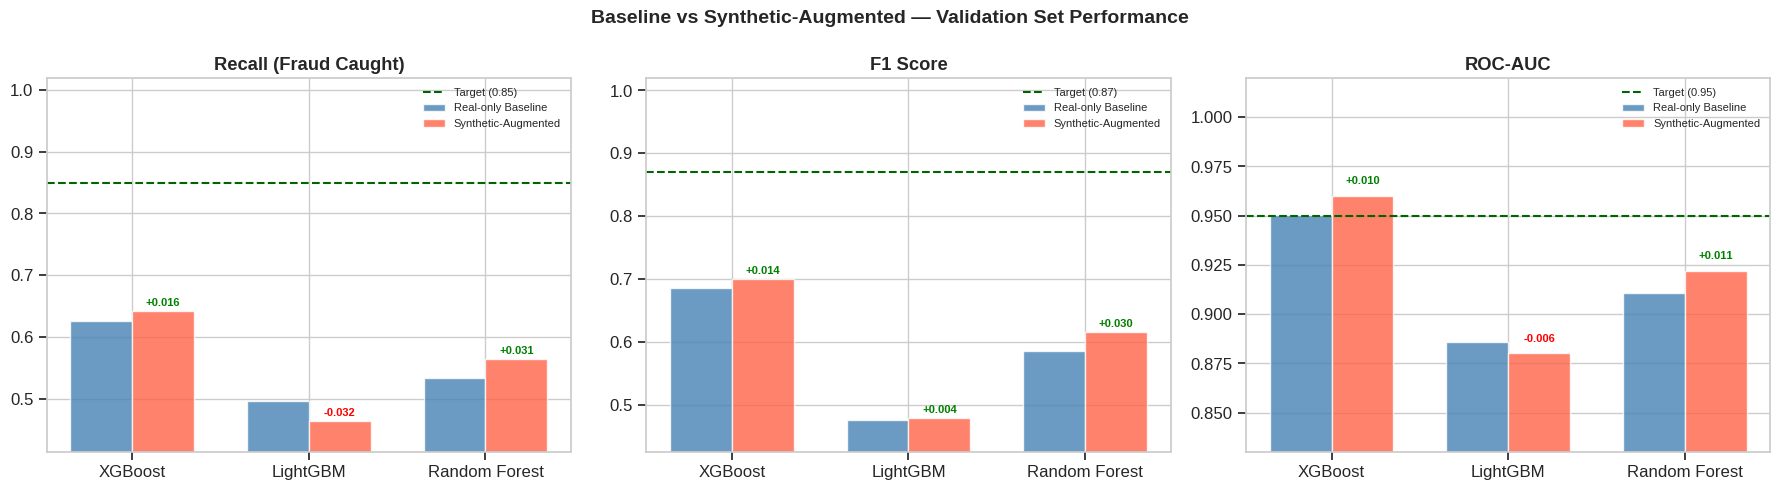

phase3_baseline_vs_augmented.png saved ✓


In [11]:

metrics = ['ROC_AUC', 'Avg_Precision', 'Recall', 'Precision', 'F1', 'FPR']

rows = []
for k, r in results_registry.items():
    row = {'Model': r['Model']}
    for m in metrics:
        row[m] = r[m]
    rows.append(row)

compare_df = pd.DataFrame(rows).sort_values('F1', ascending=False)
print('\n=== VALIDATION SET — ALL MODELS ===')
print(compare_df[['Model'] + metrics].to_string(index=False))

# ── Visual comparison (XGBoost / LightGBM / RF triplet, as before) ────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_labels = ['XGBoost', 'LightGBM', 'Random Forest']
base_keys    = ['XGBoost_baseline', 'LightGBM_baseline', 'RF_baseline']
aug_keys     = ['XGBoost_aug', 'LightGBM_aug', 'RF_aug']
x = np.arange(len(model_labels))
width = 0.35

for ax_idx, (metric, title) in enumerate([
    ('Recall',  'Recall (Fraud Caught)'),
    ('F1',      'F1 Score'),
    ('ROC_AUC', 'ROC-AUC'),
]):
    ax = axes[ax_idx]
    base_vals = [results_registry[k][metric] for k in base_keys]
    aug_vals  = [results_registry[k][metric] for k in aug_keys]
    ax.bar(x - width/2, base_vals, width, label='Real-only Baseline',
           color='steelblue', alpha=0.8, edgecolor='white')
    ax.bar(x + width/2, aug_vals,  width, label='Synthetic-Augmented',
           color='tomato',    alpha=0.8, edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(model_labels)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(max(0, min(base_vals + aug_vals) - 0.05), 1.02)
    ax.legend(fontsize=9)
    for i, (bv, av) in enumerate(zip(base_vals, aug_vals)):
        delta = av - bv
        color = 'green' if delta > 0 else 'red'
        ax.text(i + width/2, av + 0.005, f'{delta:+.3f}',
                ha='center', va='bottom', fontsize=8, color=color, fontweight='bold')
    target = {'Recall': 0.85, 'F1': 0.87, 'ROC_AUC': 0.95}.get(metric)
    if target:
        ax.axhline(target, color='darkgreen', linestyle='--', linewidth=1.5, label=f'Target ({target})')
        ax.legend(fontsize=8)

plt.suptitle('Baseline vs Synthetic-Augmented — Validation Set Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('phase3_baseline_vs_augmented.png', dpi=150, bbox_inches='tight')
plt.show()
print('phase3_baseline_vs_augmented.png saved ✓')


## 8. Hyperparameter Tuning with Optuna — Business Objective

**Change from v2**: Optuna no longer maximizes plain F1. It maximizes the weighted
business objective from the improved plan:

```
Objective = 0.5 · Recall + 0.3 · F1 + 0.2 · ROC-AUC
```

This favors catching fraud (recall) more heavily than the previous pure-F1 objective,
while still keeping precision/AUC in the loop so the model doesn't degenerate into
flagging everything. Tuned for XGBoost, LightGBM, and (if available) CatBoost.


In [14]:
N_TRIALS = 40   # increase to 80-100 for production


def compute_business_score(y_true, y_prob):
    thresh, _ = find_optimal_threshold(y_true, y_prob)
    pred = (y_prob >= thresh).astype(int)
    rec = recall_score(y_true, pred, zero_division=0)
    f1 = f1_score(y_true, pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob)
    return business_objective(rec, f1, auc)


# ------------------------------------------------------------------------------
# Detect whether XGBoost GPU is actually usable
# ------------------------------------------------------------------------------

try:
    gpu_test = xgb.XGBClassifier(
        n_estimators=1,
        tree_method="hist",
        device="cuda",
        verbosity=0,
    )
    gpu_test.fit(X_train_aug[:10], y_train_aug[:10])
    USE_GPU = True
except Exception:
    USE_GPU = False

print(f"XGBoost GPU available: {USE_GPU}")


# ------------------------------------------------------------------------------
# XGBoost Optuna Objective
# ------------------------------------------------------------------------------

def xgb_objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1200),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "scale_pos_weight": spw_aug,
        "random_state": SEED,
        "verbosity": 0,
        "eval_metric": "logloss",
        "early_stopping_rounds": 20,
    }

    if USE_GPU:
        params.update({
            "tree_method": "hist",
            "device": "cuda",
            "predictor": "auto",
            "n_jobs": 0,
        })
    else:
        params.update({
            "tree_method": "hist",
            "device": "cpu",
            "n_jobs": -1,
        })

    model = xgb.XGBClassifier(**params)

    model.fit(
        X_train_aug,
        y_train_aug,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    prob = model.predict_proba(X_val)[:, 1]

    return compute_business_score(y_val, prob)


# ------------------------------------------------------------------------------
# Run Optuna
# ------------------------------------------------------------------------------

print(f"Tuning XGBoost with Optuna ({N_TRIALS} trials, business objective)...")

t0 = time.time()

xgb_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)

xgb_study.optimize(
    xgb_objective,
    n_trials=N_TRIALS,
    show_progress_bar=True,
)

xgb_tune_time = time.time() - t0

print("\nBest XGBoost business score:", round(xgb_study.best_value, 4))
print(f"Elapsed time: {xgb_tune_time:.1f}s")
print("\nBest parameters:")
for k, v in xgb_study.best_params.items():
    print(f"{k}: {v}")

log_experiment(
    "xgboost_optuna_tuning",
    phase="phase3",
    config={
        "n_trials": N_TRIALS,
        "objective": "0.5*recall+0.3*f1+0.2*auc",
        "gpu": USE_GPU,
    },
    timing_s=xgb_tune_time,
    quality_metrics={
        "best_business_score": xgb_study.best_value,
        **xgb_study.best_params,
    },
)

XGBoost GPU available: True
Tuning XGBoost with Optuna (40 trials, business objective)...


  0%|          | 0/40 [00:00<?, ?it/s]


Best XGBoost business score: 0.8096
Elapsed time: 1606.8s

Best parameters:
n_estimators: 1060
learning_rate: 0.05156494000966238
max_depth: 10
min_child_weight: 1
subsample: 0.8111691627386142
colsample_bytree: 0.9707991386558362
gamma: 0.409131952094774
reg_alpha: 1.3930465713070157
reg_lambda: 0.0005065742671144045


{'timestamp': '2026-07-10T04:17:30.728738',
 'phase': 'phase3',
 'experiment': 'xgboost_optuna_tuning',
 'seed': 42,
 'config': '{"n_trials": 40, "objective": "0.5*recall+0.3*f1+0.2*auc", "gpu": true}',
 'timing_s': 1606.83,
 'memory_mb': None,
 'quality_metrics': '{"best_business_score": 0.809555065859457, "n_estimators": 1060, "learning_rate": 0.05156494000966238, "max_depth": 10, "min_child_weight": 1, "subsample": 0.8111691627386142, "colsample_bytree": 0.9707991386558362, "gamma": 0.409131952094774, "reg_alpha": 1.3930465713070157, "reg_lambda": 0.0005065742671144045}',
 'val_metrics': '{}',
 'test_metrics': '{}',
 'notes': ''}

Tuning LightGBM with Optuna (40 trials, business objective)...


  0%|          | 0/40 [00:00<?, ?it/s]

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Best LightGBM business score: 0.6599
Elapsed: 645s
{'n_estimators': 1171, 'learning_rate': 0.010096295893104722, 'max_depth': 10, 'num_leaves': 255, 'min_child_samples': 59, 'subsample': 0.8384090290478076, 'colsample_bytree': 0.5301678563976088, 'reg_alpha': 0.06420928819740941, 'reg_lambda': 0.009414439540471999}

Tuning CatBoost with Optuna (25 trials, business objective)...


  0%|          | 0/25 [00:00<?, ?it/s]

Best CatBoost business score: 0.7436
Elapsed: 505s
{'iterations': 892, 'learning_rate': 0.09349861445280216, 'depth': 10, 'l2_leaf_reg': 9.309107949780511}


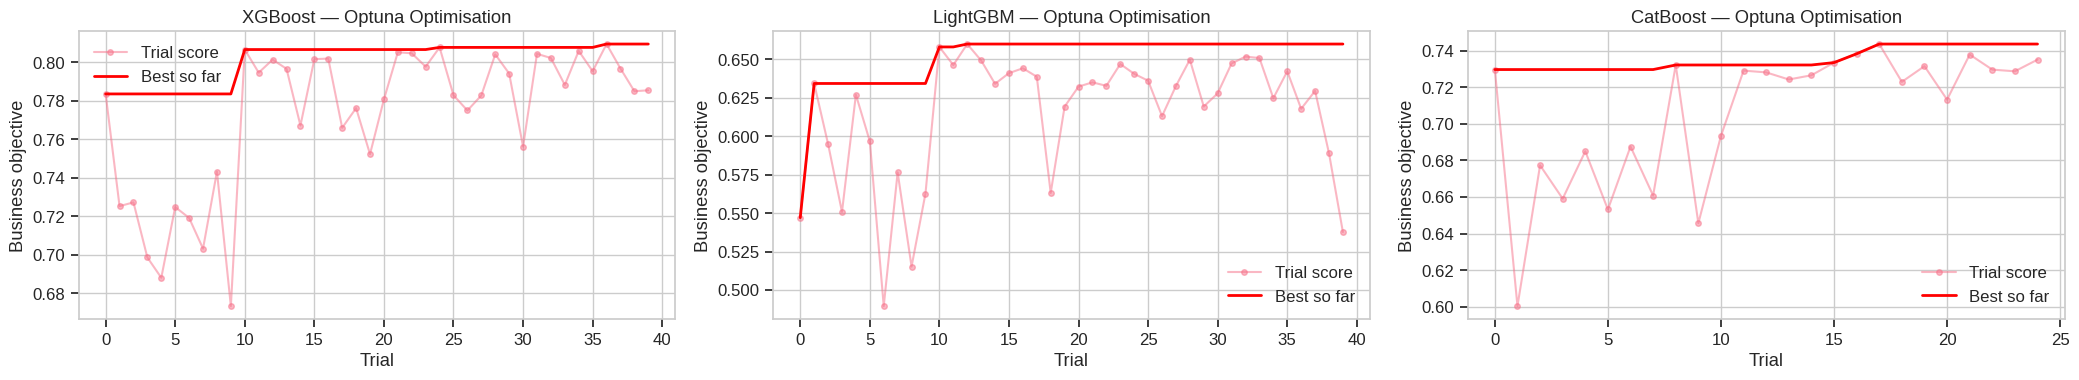

phase3_optuna_history.png saved ✓


In [15]:
# ── LightGBM Optuna Study ─────────────────────────────────────────────────────

def lgb_objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'num_leaves': trial.suggest_int('num_leaves', 31, 255),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'scale_pos_weight': spw_aug,
        'random_state': SEED,
        'verbosity': -1,
    }

    try:
        params.update({
            'device': 'gpu',
            'n_jobs': 0,
        })

        model = lgb.LGBMClassifier(**params)

        model.fit(
            X_train_aug,
            y_train_aug,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(20, verbose=False),
                lgb.log_evaluation(-1)
            ]
        )

    except Exception:

        params.update({
            'device': 'cpu',
            'n_jobs': -1,
        })

        model = lgb.LGBMClassifier(**params)

        model.fit(
            X_train_aug,
            y_train_aug,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(20, verbose=False),
                lgb.log_evaluation(-1)
            ]
        )

    prob = model.predict_proba(X_val)[:, 1]

    return compute_business_score(y_val, prob)


print(f'Tuning LightGBM with Optuna ({N_TRIALS} trials, business objective)...')

t0 = time.time()

lgb_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED)
)

lgb_study.optimize(
    lgb_objective,
    n_trials=N_TRIALS,
    show_progress_bar=True
)

lgb_tune_time = time.time() - t0

print(f'Best LightGBM business score: {lgb_study.best_value:.4f}')
print(f'Elapsed: {lgb_tune_time:.0f}s')
print(lgb_study.best_params)

log_experiment(
    'lightgbm_optuna_tuning',
    phase='phase3',
    config={
        'n_trials': N_TRIALS,
        'objective': '0.5*recall+0.3*f1+0.2*auc'
    },
    timing_s=lgb_tune_time,
    quality_metrics={
        'best_business_score': lgb_study.best_value,
        **lgb_study.best_params
    }
)


# ── CatBoost Optuna Study ─────────────────────────────────────────────────────

if CATBOOST_OK:

    def cat_objective(trial):

        params = {
            'iterations': trial.suggest_int('iterations', 300, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0, log=True),
            'scale_pos_weight': spw_aug,
            'random_seed': SEED,
            'verbose': False,
            'early_stopping_rounds': 20,
        }

        try:

            params.update({
                'task_type': 'GPU',
                'devices': '0'
            })

            model = CatBoostClassifier(**params)

            model.fit(
                X_train_aug,
                y_train_aug,
                eval_set=(X_val, y_val),
                verbose=False
            )

        except Exception:

            params.update({
                'task_type': 'CPU'
            })

            model = CatBoostClassifier(**params)

            model.fit(
                X_train_aug,
                y_train_aug,
                eval_set=(X_val, y_val),
                verbose=False
            )

        prob = model.predict_proba(X_val)[:, 1]

        return compute_business_score(y_val, prob)


    print(f'\nTuning CatBoost with Optuna ({min(N_TRIALS,25)} trials, business objective)...')

    t0 = time.time()

    cat_study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=SEED)
    )

    cat_study.optimize(
        cat_objective,
        n_trials=min(N_TRIALS, 25),
        show_progress_bar=True
    )

    cat_tune_time = time.time() - t0

    print(f'Best CatBoost business score: {cat_study.best_value:.4f}')
    print(f'Elapsed: {cat_tune_time:.0f}s')
    print(cat_study.best_params)

    log_experiment(
        'catboost_optuna_tuning',
        phase='phase3',
        config={
            'n_trials': min(N_TRIALS,25),
            'objective': '0.5*recall+0.3*f1+0.2*auc'
        },
        timing_s=cat_tune_time,
        quality_metrics={
            'best_business_score': cat_study.best_value,
            **cat_study.best_params
        }
    )

else:
    cat_study = None


# ── Optuna Optimisation History ───────────────────────────────────────────────

studies_to_plot = [
    ('XGBoost', xgb_study),
    ('LightGBM', lgb_study),
]

if cat_study is not None:
    studies_to_plot.append(('CatBoost', cat_study))

fig, axes = plt.subplots(
    1,
    len(studies_to_plot),
    figsize=(7 * len(studies_to_plot), 4)
)

if len(studies_to_plot) == 1:
    axes = [axes]

for ax, (name, study) in zip(axes, studies_to_plot):

    df = study.trials_dataframe()

    ax.plot(
        df['number'],
        df['value'],
        'o-',
        ms=4,
        alpha=0.5,
        label='Trial score'
    )

    ax.plot(
        df['number'],
        df['value'].cummax(),
        'r-',
        lw=2,
        label='Best so far'
    )

    ax.set_xlabel('Trial')
    ax.set_ylabel('Business objective')
    ax.set_title(f'{name} — Optuna Optimisation')
    ax.legend()

plt.tight_layout()
plt.savefig('phase3_optuna_history.png', dpi=150, bbox_inches='tight')
plt.show()

print('phase3_optuna_history.png saved ✓')

## 9. Train Best Tuned Models

In [16]:
print('Training tuned models with Optuna best params …')
print()

# ──────────────────────────────────────────────────────────────────────────────
# Tuned XGBoost
# ──────────────────────────────────────────────────────────────────────────────

best_xgb_params = xgb_study.best_params.copy()

best_xgb_params.update({
    'scale_pos_weight': spw_aug,
    'random_state': SEED,
    'verbosity': 0,
    'eval_metric': 'logloss',
    'early_stopping_rounds': 40,
})

try:
    best_xgb_params.update({
        'tree_method': 'hist',
        'device': 'cuda',
        'predictor': 'auto',
        'n_jobs': 0,
    })

    print('[1/3] Tuned XGBoost (GPU) ...')

    t0 = time.time()

    xgb_tuned = xgb.XGBClassifier(**best_xgb_params)

    xgb_tuned.fit(
        X_train_aug,
        y_train_aug,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

except Exception:

    print('GPU unavailable. Falling back to CPU.')

    best_xgb_params.update({
        'tree_method': 'hist',
        'device': 'cpu',
        'n_jobs': -1,
    })

    t0 = time.time()

    xgb_tuned = xgb.XGBClassifier(**best_xgb_params)

    xgb_tuned.fit(
        X_train_aug,
        y_train_aug,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

prob = xgb_tuned.predict_proba(X_val)[:, 1]

r_xgb_tuned = full_eval(
    'XGBoost (tuned, augmented)',
    y_val,
    prob
)

results_registry['XGBoost_tuned'] = r_xgb_tuned

print(f'  Training time: {time.time()-t0:.1f}s')

log_experiment(
    'XGBoost_tuned',
    phase='phase3',
    timing_s=time.time()-t0,
    val_metrics=r_xgb_tuned
)


# ──────────────────────────────────────────────────────────────────────────────
# Tuned LightGBM
# ──────────────────────────────────────────────────────────────────────────────

best_lgb_params = lgb_study.best_params.copy()

best_lgb_params.update({
    'scale_pos_weight': spw_aug,
    'random_state': SEED,
    'verbosity': -1,
})

print()
print('[2/3] Tuned LightGBM ...')

try:

    best_lgb_params.update({
        'device': 'gpu',
        'n_jobs': 0,
    })

    t0 = time.time()

    lgb_tuned = lgb.LGBMClassifier(**best_lgb_params)

    lgb_tuned.fit(
        X_train_aug,
        y_train_aug,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(40, verbose=False),
            lgb.log_evaluation(-1),
        ],
    )

except Exception:

    print('GPU unavailable. Falling back to CPU.')

    best_lgb_params.update({
        'device': 'cpu',
        'n_jobs': -1,
    })

    t0 = time.time()

    lgb_tuned = lgb.LGBMClassifier(**best_lgb_params)

    lgb_tuned.fit(
        X_train_aug,
        y_train_aug,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(40, verbose=False),
            lgb.log_evaluation(-1),
        ],
    )

prob = lgb_tuned.predict_proba(X_val)[:, 1]

r_lgb_tuned = full_eval(
    'LightGBM (tuned, augmented)',
    y_val,
    prob
)

results_registry['LightGBM_tuned'] = r_lgb_tuned

print(f'  Training time: {time.time()-t0:.1f}s')

log_experiment(
    'LightGBM_tuned',
    phase='phase3',
    timing_s=time.time()-t0,
    val_metrics=r_lgb_tuned
)


# ──────────────────────────────────────────────────────────────────────────────
# Tuned CatBoost
# ──────────────────────────────────────────────────────────────────────────────

if CATBOOST_OK and cat_study is not None:

    best_cat_params = cat_study.best_params.copy()

    best_cat_params.update({
        'scale_pos_weight': spw_aug,
        'random_seed': SEED,
        'verbose': False,
        'early_stopping_rounds': 40,
    })

    print()
    print('[3/3] Tuned CatBoost ...')

    try:

        best_cat_params.update({
            'task_type': 'GPU',
            'devices': '0',
        })

        t0 = time.time()

        cat_tuned = CatBoostClassifier(**best_cat_params)

        cat_tuned.fit(
            X_train_aug,
            y_train_aug,
            eval_set=(X_val, y_val),
            verbose=False,
        )

    except Exception:

        print('GPU unavailable. Falling back to CPU.')

        best_cat_params.update({
            'task_type': 'CPU',
        })

        t0 = time.time()

        cat_tuned = CatBoostClassifier(**best_cat_params)

        cat_tuned.fit(
            X_train_aug,
            y_train_aug,
            eval_set=(X_val, y_val),
            verbose=False,
        )

    prob = cat_tuned.predict_proba(X_val)[:, 1]

    r_cat_tuned = full_eval(
        'CatBoost (tuned, augmented)',
        y_val,
        prob
    )

    results_registry['CatBoost_tuned'] = r_cat_tuned

    print(f'  Training time: {time.time()-t0:.1f}s')

    log_experiment(
        'CatBoost_tuned',
        phase='phase3',
        timing_s=time.time()-t0,
        val_metrics=r_cat_tuned
    )

else:

    cat_tuned = None

Training tuned models with Optuna best params …

[1/3] Tuned XGBoost (GPU) ...
XGBoost (tuned, augmented)          | ROC-AUC: 0.9711  AP: 0.8491  Recall: 0.7464  Prec: 0.8788  F1: 0.8072  FPR: 0.0037  thr=0.431
  Training time: 58.4s

[2/3] Tuned LightGBM ...
LightGBM (tuned, augmented)         | ROC-AUC: 0.9318  AP: 0.6589  Recall: 0.5705  Prec: 0.6972  F1: 0.6275  FPR: 0.0090  thr=0.220
  Training time: 19.4s

[3/3] Tuned CatBoost ...
CatBoost (tuned, augmented)         | ROC-AUC: 0.9624  AP: 0.7768  Recall: 0.6651  Prec: 0.8060  F1: 0.7288  FPR: 0.0058  thr=0.716
  Training time: 27.9s


## 10. Probability Calibration — Platt / Isotonic

Before threshold optimization (Phase 3.5), calibrate each tuned model's output
probabilities. Tree-ensemble probabilities are often poorly calibrated (over-confident
near 0/1), which distorts any cost-based threshold search downstream. We try both
Platt scaling (`sigmoid`) and Isotonic regression and keep whichever gives the lower
Brier score on the validation set.


In [18]:

def calibrate_and_pick_best(name, base_model, X_tr_cal, y_tr_cal, X_val, y_val):
    # Fit both Platt (sigmoid) and Isotonic calibration using cv=5 on a copy of the base
    # estimator, then keep whichever has the lower Brier score on the validation set.
    candidates = {}
    for method in ['sigmoid', 'isotonic']:
        try:
            cal = CalibratedClassifierCV(
                estimator=base_model,
                method=method,
                cv=5,
                n_jobs=-1
            )
            cal.fit(X_tr_cal, y_tr_cal)
            prob = cal.predict_proba(X_val)[:, 1]
            brier = brier_score_loss(y_val, prob)
            candidates[method] = (cal, brier, prob)
        except Exception as e:
            print(f'    [{name}] {method} calibration failed: {e}')
    if not candidates:
        return None, None, None
    best_method = min(candidates, key=lambda m: candidates[m][1])
    cal_model, brier, prob = candidates[best_method]
    print(f'  {name:30s} | Platt Brier={candidates.get("sigmoid", (None,np.nan,None))[1]:.5f}  '
          f'Isotonic Brier={candidates.get("isotonic", (None,np.nan,None))[1]:.5f}  → using {best_method}')
    return cal_model, best_method, prob

print('Calibrating tuned models (Platt vs Isotonic, lower Brier score wins) …')
print()

t0 = time.time()
calibrated_models = {}

for name, base in [('XGBoost_tuned', xgb_tuned), ('LightGBM_tuned', lgb_tuned)] + \
                   ([('CatBoost_tuned', cat_tuned)] if cat_tuned is not None else []):
    cal_model, method, cal_prob = calibrate_and_pick_best(name, base, X_train_aug, y_train_aug, X_val, y_val)
    if cal_model is not None:
        r_cal = full_eval(f'{name} (calibrated, {method})', y_val, cal_prob)
        results_registry[f'{name}_calibrated'] = r_cal
        calibrated_models[name] = {'model': cal_model, 'method': method}

calib_time = time.time() - t0
print(f'\nCalibration complete ✓  ({calib_time:.1f}s)')
log_experiment('probability_calibration', phase='phase3',
               config={'models_calibrated': list(calibrated_models.keys())},
               timing_s=calib_time,
               notes='Platt vs Isotonic per model, lower Brier score selected')

# ── Reliability diagram (calibration curve) ───────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
for name, base in [('XGBoost_tuned', xgb_tuned), ('LightGBM_tuned', lgb_tuned)]:
    raw_prob = base.predict_proba(X_val)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_val, raw_prob, n_bins=15, strategy='quantile')
    ax.plot(mean_pred, frac_pos, 's-', alpha=0.6, label=f'{name} (raw)')
    if name in calibrated_models:
        cal_prob = calibrated_models[name]['model'].predict_proba(X_val)[:, 1]
        frac_pos_c, mean_pred_c = calibration_curve(y_val, cal_prob, n_bins=15, strategy='quantile')
        ax.plot(mean_pred_c, frac_pos_c, 'o-', alpha=0.8, label=f'{name} (calibrated)')
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Fraction of positives')
ax.set_title('Reliability Diagram — Raw vs Calibrated Probabilities')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('phase3_calibration_curves.png', dpi=130, bbox_inches='tight')
plt.show()
print('phase3_calibration_curves.png saved ✓')


Calibrating tuned models (Platt vs Isotonic, lower Brier score wins) …

    [XGBoost_tuned] sigmoid calibration failed: Must have at least 1 validation dataset for early stopping.
    [XGBoost_tuned] isotonic calibration failed: Must have at least 1 validation dataset for early stopping.


KeyboardInterrupt: 

Calibrating tuned models (Platt vs Isotonic)...

XGBoost_tuned                  | Platt=0.01112 | Isotonic=0.01085 → isotonic
XGBoost_tuned (calibrated, isotonic) | ROC-AUC: 0.9718  AP: 0.8454  Recall: 0.7480  Prec: 0.8538  F1: 0.7974  FPR: 0.0046  thr=0.338


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

LightGBM_tuned                 | Platt=0.01488 | Isotonic=0.01427 → isotonic
LightGBM_tuned (calibrated, isotonic) | ROC-AUC: 0.9612  AP: 0.7684  Recall: 0.6225  Prec: 0.8461  F1: 0.7172  FPR: 0.0041  thr=0.407
    [CatBoost_tuned] sigmoid calibration failed: Cannot clone object CatBoostClassifier(depth=10, devices='0', early_stopping_rounds=40, iterations=892, l2_leaf_reg=9.309107949780511, learning_rate=0.09349861445280216, random_seed=42, scale_pos_weight=np.float64(13.7898921460177), task_type='GPU', verbose=False), as the constructor either does not set or modifies parameter scale_pos_weight
    [CatBoost_tuned] isotonic calibration failed: Cannot clone object CatBoostClassifier(depth=10, devices='0', early_stopping_rounds=40, iterations=892, l2_leaf_reg=9.309107949780511, learning_rate=0.09349861445280216, random_seed=42, scale_pos_weight=np.float64(13.7898921460177), task_type='GPU', verbose=False), as the constructor either does not set or modifies parameter scale_pos_weight

C

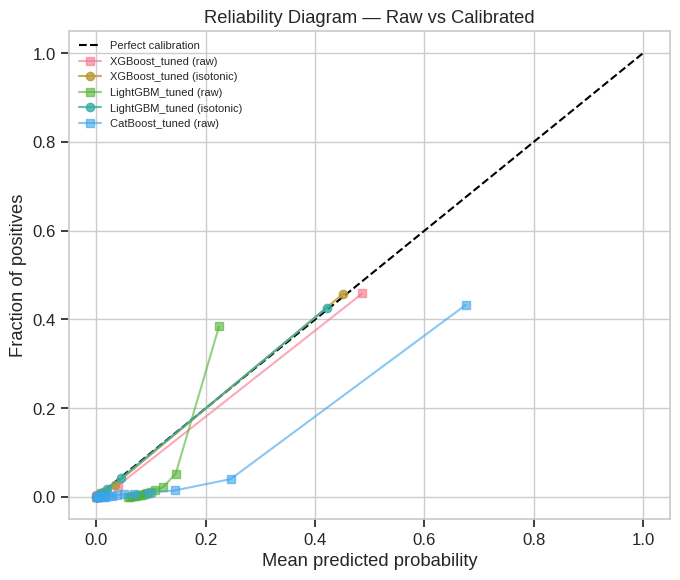

phase3_calibration_curves.png saved ✓


In [19]:
from sklearn.base import clone

def calibrate_and_pick_best(name, base_model, X_tr_cal, y_tr_cal, X_val, y_val):
    """
    Fit both Platt (sigmoid) and Isotonic calibration and keep the one
    with the lowest Brier score on the validation set.
    """

    candidates = {}

    for method in ["sigmoid", "isotonic"]:

        try:
            # Clone estimator so the original trained model is untouched
            est = clone(base_model)

            # Remove early stopping parameters if present
            params = est.get_params()

            remove_params = {}

            if "early_stopping_rounds" in params:
                remove_params["early_stopping_rounds"] = None

            if "callbacks" in params:
                remove_params["callbacks"] = None

            if remove_params:
                est.set_params(**remove_params)

            cal = CalibratedClassifierCV(
                estimator=est,
                method=method,
                cv=5,
                n_jobs=-1,
            )

            cal.fit(X_tr_cal, y_tr_cal)

            prob = cal.predict_proba(X_val)[:, 1]

            brier = brier_score_loss(y_val, prob)

            candidates[method] = {
                "model": cal,
                "brier": brier,
                "prob": prob,
            }

        except Exception as e:
            print(f"    [{name}] {method} calibration failed: {e}")

    if len(candidates) == 0:
        return None, None, None

    best_method = min(
        candidates.keys(),
        key=lambda k: candidates[k]["brier"]
    )

    print(
        f"{name:30s} | "
        f"Platt={candidates.get('sigmoid',{'brier':np.nan})['brier']:.5f} | "
        f"Isotonic={candidates.get('isotonic',{'brier':np.nan})['brier']:.5f} "
        f"→ {best_method}"
    )

    return (
        candidates[best_method]["model"],
        best_method,
        candidates[best_method]["prob"],
    )


print("Calibrating tuned models (Platt vs Isotonic)...")
print()

t0 = time.time()

calibrated_models = {}

models = [
    ("XGBoost_tuned", xgb_tuned),
    ("LightGBM_tuned", lgb_tuned),
]

if cat_tuned is not None:
    models.append(("CatBoost_tuned", cat_tuned))

for name, model in models:

    cal_model, method, cal_prob = calibrate_and_pick_best(
        name,
        model,
        X_train_aug,
        y_train_aug,
        X_val,
        y_val,
    )

    if cal_model is None:
        continue

    calibrated_models[name] = {
        "model": cal_model,
        "method": method,
    }

    r = full_eval(
        f"{name} (calibrated, {method})",
        y_val,
        cal_prob,
    )

    results_registry[f"{name}_calibrated"] = r

calib_time = time.time() - t0

print(f"\nCalibration complete ✓ ({calib_time:.1f}s)")

log_experiment(
    "probability_calibration",
    phase="phase3",
    config={
        "models_calibrated": list(calibrated_models.keys())
    },
    timing_s=calib_time,
    notes="Platt vs Isotonic (lowest Brier score selected)",
)

# ──────────────────────────────────────────────────────────────
# Reliability Diagram
# ──────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Perfect calibration",
)

for name, model in models:

    raw_prob = model.predict_proba(X_val)[:, 1]

    frac_pos, mean_pred = calibration_curve(
        y_val,
        raw_prob,
        n_bins=15,
        strategy="quantile",
    )

    ax.plot(
        mean_pred,
        frac_pos,
        "s-",
        alpha=0.6,
        label=f"{name} (raw)",
    )

    if name in calibrated_models:

        cal_prob = calibrated_models[name]["model"].predict_proba(X_val)[:, 1]

        frac_pos_c, mean_pred_c = calibration_curve(
            y_val,
            cal_prob,
            n_bins=15,
            strategy="quantile",
        )

        ax.plot(
            mean_pred_c,
            frac_pos_c,
            "o-",
            alpha=0.8,
            label=f"{name} ({calibrated_models[name]['method']})",
        )

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Reliability Diagram — Raw vs Calibrated")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("phase3_calibration_curves.png", dpi=130, bbox_inches="tight")
plt.show()

print("phase3_calibration_curves.png saved ✓")

## 11. Stratified 5-Fold Cross-Validation

Validates the best tuned models with 5-fold stratified CV on the augmented training set,
confirming the model is not overfitting to a single train/val split.


In [20]:

print('=== 5-Fold Stratified Cross-Validation (on augmented train) ===')
print()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_summary = {}

def cv_run(name, clf_factory, X, y, is_lgb=False):
    fold_metrics = []
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        clf = clf_factory()
        X_tr, X_v = X[tr_idx], X[val_idx]
        y_tr, y_v = y[tr_idx], y[val_idx]
        if is_lgb:
            clf.fit(X_tr, y_tr, eval_set=[(X_v, y_v)],
                    callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(-1)])
        else:
            clf.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], verbose=False)
        prob = clf.predict_proba(X_v)[:, 1]
        thresh, _ = find_optimal_threshold(y_v, prob)
        pred = (prob >= thresh).astype(int)
        fold_metrics.append({
            'ROC_AUC':       roc_auc_score(y_v, prob),
            'Avg_Precision': average_precision_score(y_v, prob),
            'F1':            f1_score(y_v, pred, zero_division=0),
            'Recall':        recall_score(y_v, pred, zero_division=0),
            'Precision':     precision_score(y_v, pred, zero_division=0),
        })
        print(f'  Fold {fold+1}/5  F1={fold_metrics[-1]["F1"]:.4f}  '
              f'Recall={fold_metrics[-1]["Recall"]:.4f}  AUC={fold_metrics[-1]["ROC_AUC"]:.4f}')
    m = pd.DataFrame(fold_metrics)
    summary = {col: f'{m[col].mean():.4f} ± {m[col].std():.4f}' for col in m.columns}
    cv_summary[name] = summary
    print(f'  ── Summary: F1={summary["F1"]}  Recall={summary["Recall"]}  AUC={summary["ROC_AUC"]}')
    return m

t_cv = time.time()

print('[1/2] Cross-validating Tuned XGBoost …')
xgb_cv_params = best_xgb_params.copy()
xgb_cv_params['n_estimators'] = min(xgb_cv_params.get('n_estimators', 600), 600)
cv_run('XGBoost_tuned', lambda: xgb.XGBClassifier(**xgb_cv_params), X_train_aug, y_train_aug)

print()
print('[2/2] Cross-validating Tuned LightGBM …')
lgb_cv_params = best_lgb_params.copy()
lgb_cv_params['n_estimators'] = min(lgb_cv_params.get('n_estimators', 600), 600)
cv_run('LightGBM_tuned', lambda: lgb.LGBMClassifier(**lgb_cv_params), X_train_aug, y_train_aug, is_lgb=True)

print()
print('5-Fold CV complete ✓')
cv_df = pd.DataFrame(cv_summary).T
print(cv_df)

log_experiment('phase3_5fold_cv', phase='phase3', timing_s=time.time()-t_cv,
               val_metrics=cv_summary)


=== 5-Fold Stratified Cross-Validation (on augmented train) ===

[1/2] Cross-validating Tuned XGBoost …
  Fold 1/5  F1=0.8888  Recall=0.8458  AUC=0.9825
  Fold 2/5  F1=0.8836  Recall=0.8242  AUC=0.9801
  Fold 3/5  F1=0.8899  Recall=0.8344  AUC=0.9816
  Fold 4/5  F1=0.8901  Recall=0.8404  AUC=0.9824
  Fold 5/5  F1=0.8881  Recall=0.8379  AUC=0.9817
  ── Summary: F1=0.8881 ± 0.0026  Recall=0.8366 ± 0.0081  AUC=0.9817 ± 0.0010

[2/2] Cross-validating Tuned LightGBM …
  Fold 1/5  F1=0.8615  Recall=0.7976  AUC=0.9759
  Fold 2/5  F1=0.8548  Recall=0.7803  AUC=0.9750
  Fold 3/5  F1=0.8588  Recall=0.7801  AUC=0.9759
  Fold 4/5  F1=0.8611  Recall=0.7912  AUC=0.9767
  Fold 5/5  F1=0.8561  Recall=0.7950  AUC=0.9746
  ── Summary: F1=0.8585 ± 0.0030  Recall=0.7889 ± 0.0082  AUC=0.9756 ± 0.0008

5-Fold CV complete ✓
                        ROC_AUC    Avg_Precision               F1  \
XGBoost_tuned   0.9817 ± 0.0010  0.9291 ± 0.0020  0.8881 ± 0.0026   
LightGBM_tuned  0.9756 ± 0.0008  0.9052 ± 0.0023 

{'timestamp': '2026-07-10T05:21:05.744706',
 'phase': 'phase3',
 'experiment': 'phase3_5fold_cv',
 'seed': 42,
 'config': '{}',
 'timing_s': 581.48,
 'memory_mb': None,
 'quality_metrics': '{}',
 'val_metrics': '{"XGBoost_tuned": {"ROC_AUC": "0.9817 \\u00b1 0.0010", "Avg_Precision": "0.9291 \\u00b1 0.0020", "F1": "0.8881 \\u00b1 0.0026", "Recall": "0.8366 \\u00b1 0.0081", "Precision": "0.9465 \\u00b1 0.0069"}, "LightGBM_tuned": {"ROC_AUC": "0.9756 \\u00b1 0.0008", "Avg_Precision": "0.9052 \\u00b1 0.0023", "F1": "0.8585 \\u00b1 0.0030", "Recall": "0.7889 \\u00b1 0.0082", "Precision": "0.9417 \\u00b1 0.0104"}}',
 'test_metrics': '{}',
 'notes': ''}

## 12. Soft-Voting Ensemble — Automatically-Tuned Weights

Instead of picking a single best model, blend XGBoost / CatBoost / LightGBM probabilities
with weights optimized on the validation set (starting point 40/30/30 per the plan, then
refined by a constrained optimizer maximizing the same business objective used for Optuna).


In [21]:

t0 = time.time()

ensemble_members = {'XGBoost': xgb_tuned, 'LightGBM': lgb_tuned}
if cat_tuned is not None:
    ensemble_members['CatBoost'] = cat_tuned

member_val_probs = {name: m.predict_proba(X_val)[:, 1] for name, m in ensemble_members.items()}
member_names = list(ensemble_members.keys())
n_members = len(member_names)

def neg_business_score_for_weights(w):
    w = np.clip(w, 0, None)
    w = w / (w.sum() + 1e-12)
    blended = sum(wi * member_val_probs[name] for wi, name in zip(w, member_names))
    return -compute_business_score(y_val, blended)

# Starting point: 40% XGBoost / 30% CatBoost / 30% LightGBM (or renormalized if CatBoost missing)
if n_members == 3:
    init_w = np.array([0.40, 0.30, 0.30])  # XGBoost, LightGBM, CatBoost order matches member_names below
    # member_names order is insertion order: XGBoost, LightGBM, CatBoost
    init_w = np.array([0.40, 0.30, 0.30])
else:
    init_w = np.ones(n_members) / n_members

bounds = [(0.0, 1.0)] * n_members
constraint = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
opt_result = minimize(neg_business_score_for_weights, init_w, method='SLSQP',
                      bounds=bounds, constraints=[constraint], options={'maxiter': 200})

tuned_weights = np.clip(opt_result.x, 0, None)
tuned_weights = tuned_weights / tuned_weights.sum()
weight_map = dict(zip(member_names, tuned_weights))

print('Ensemble members :', member_names)
print('Initial weights  :', dict(zip(member_names, init_w)))
print('Tuned weights    :', {k: round(v, 3) for k, v in weight_map.items()})

ensemble_val_prob = sum(weight_map[name] * member_val_probs[name] for name in member_names)
r_ensemble = full_eval('Soft-Voting Ensemble (tuned weights)', y_val, ensemble_val_prob)
results_registry['Ensemble_tuned'] = r_ensemble

ensemble_time = time.time() - t0
print(f'\nEnsemble weight tuning time: {ensemble_time:.1f}s')
log_experiment('soft_voting_ensemble', phase='phase3',
               config={'members': member_names, 'weights': {k: round(v,4) for k,v in weight_map.items()}},
               timing_s=ensemble_time, val_metrics=r_ensemble)

def ensemble_predict_proba(X):
    # Blend member model probabilities using the tuned weight map.
    probs = {name: m.predict_proba(X)[:, 1] for name, m in ensemble_members.items()}
    return sum(weight_map[name] * probs[name] for name in member_names)


Ensemble members : ['XGBoost', 'LightGBM', 'CatBoost']
Initial weights  : {'XGBoost': np.float64(0.4), 'LightGBM': np.float64(0.3), 'CatBoost': np.float64(0.3)}
Tuned weights    : {'XGBoost': np.float64(0.4), 'LightGBM': np.float64(0.3), 'CatBoost': np.float64(0.3)}
Soft-Voting Ensemble (tuned weights) | ROC-AUC: 0.9672  AP: 0.8280  Recall: 0.7264  Prec: 0.8579  F1: 0.7867  FPR: 0.0044  thr=0.429

Ensemble weight tuning time: 1.6s


## 13. Model Selection — Rank All Candidates, Pick the Winner

In [22]:

all_rows = []
for k, r in results_registry.items():
    all_rows.append({m: r[m] for m in ['Model','ROC_AUC','Avg_Precision','Recall','Precision','F1','FPR','Threshold']})

full_df = pd.DataFrame(all_rows).sort_values('F1', ascending=False).reset_index(drop=True)
full_df.index += 1
print('=== ALL MODELS — VALIDATION SET RANKING (by F1) ===')
print(full_df[['Model','ROC_AUC','Avg_Precision','Recall','Precision','F1','FPR','Threshold']].to_string())

print('\n=== SUCCESS CRITERIA CHECK ===')
targets = {'Recall': 0.85, 'Precision': 0.90, 'F1': 0.87, 'ROC_AUC': 0.95}
best_row = full_df.iloc[0]
for metric, target in targets.items():
    val = best_row[metric]
    status = '✅' if val >= target else '❌'
    print(f'  {status} {metric:15s}: {val:.4f}  (target: ≥{target})')

best_model_name = best_row['Model']
best_threshold  = best_row['Threshold']
print(f'\n🏆 Best model (by validation F1): {best_model_name}  (val F1={best_row["F1"]:.4f})')

# Map name → fitted object (or callable, for the ensemble)
name_map = {
    'XGBoost (real-only)':             ('XGBoost_baseline',  xgb_base),
    'LightGBM (real-only)':            ('LightGBM_baseline', lgb_base),
    'Random Forest (real-only)':       ('RF_baseline',       rf_base),
    'XGBoost (augmented)':             ('XGBoost_aug',       xgb_aug),
    'LightGBM (augmented)':            ('LightGBM_aug',      lgb_aug),
    'Random Forest (augmented)':       ('RF_aug',            rf_aug),
    'XGBoost (tuned, augmented)':      ('XGBoost_tuned',     xgb_tuned),
    'LightGBM (tuned, augmented)':     ('LightGBM_tuned',    lgb_tuned),
    'Soft-Voting Ensemble (tuned weights)': ('Ensemble_tuned', 'ENSEMBLE'),
}
if cat_base is not None:
    name_map['CatBoost (real-only)'] = ('CatBoost_baseline', cat_base)
if cat_aug is not None:
    name_map['CatBoost (augmented)'] = ('CatBoost_aug', cat_aug)
if cat_tuned is not None:
    name_map['CatBoost (tuned, augmented)'] = ('CatBoost_tuned', cat_tuned)
if brf_base is not None:
    name_map['Balanced RF (real-only)'] = ('BalancedRF_baseline', brf_base)
    name_map['Easy Ensemble (real-only)'] = ('EasyEnsemble_baseline', eec_base)
if brf_aug is not None:
    name_map['Balanced RF (augmented)'] = ('BalancedRF_aug', brf_aug)
    name_map['Easy Ensemble (augmented)'] = ('EasyEnsemble_aug', eec_aug)

_, best_clf_obj = name_map.get(best_model_name, ('XGBoost_tuned', xgb_tuned))
IS_ENSEMBLE_WINNER = (best_clf_obj == 'ENSEMBLE')
print(f'Winner object  : {"Soft-Voting Ensemble" if IS_ENSEMBLE_WINNER else type(best_clf_obj).__name__}')

log_experiment('model_selection', phase='phase3',
               config={'winner': best_model_name}, val_metrics=dict(best_row))


=== ALL MODELS — VALIDATION SET RANKING (by F1) ===
                                    Model  ROC_AUC  Avg_Precision  Recall  Precision      F1     FPR  Threshold
1              XGBoost (tuned, augmented)   0.9711         0.8491  0.7464     0.8788  0.8072  0.0037     0.4312
2    XGBoost_tuned (calibrated, isotonic)   0.9718         0.8454  0.7480     0.8538  0.7974  0.0046     0.3382
3    Soft-Voting Ensemble (tuned weights)   0.9672         0.8280  0.7264     0.8579  0.7867  0.0044     0.4286
4             CatBoost (tuned, augmented)   0.9624         0.7768  0.6651     0.8060  0.7288  0.0058     0.7163
5   LightGBM_tuned (calibrated, isotonic)   0.9612         0.7684  0.6225     0.8461  0.7172  0.0041     0.4070
6                     XGBoost (augmented)   0.9600         0.7527  0.6421     0.7689  0.6998  0.0070     0.7536
7                     XGBoost (real-only)   0.9504         0.7274  0.6257     0.7574  0.6853  0.0073     0.7289
8                    CatBoost (augmented)   0.9491  

{'timestamp': '2026-07-10T05:21:07.347848',
 'phase': 'phase3',
 'experiment': 'model_selection',
 'seed': 42,
 'config': '{"winner": "XGBoost (tuned, augmented)"}',
 'timing_s': None,
 'memory_mb': None,
 'quality_metrics': '{}',
 'val_metrics': '{"Model": "XGBoost (tuned, augmented)", "ROC_AUC": 0.9711, "Avg_Precision": 0.8491, "Recall": 0.7464, "Precision": 0.8788, "F1": 0.8072, "FPR": 0.0037, "Threshold": 0.4311999976634979}',
 'test_metrics': '{}',
 'notes': ''}

## 14. Final Retrain on Train+Val → Test Set Evaluation

Re-train the best model (or reconstruct the ensemble) on the combined train+val data,
then evaluate once on the held-out test set (original distribution only, no synthetic).


In [24]:

X_trainval = np.vstack([X_train_aug, X_val])
y_trainval = np.concatenate([y_train_aug, y_val])
spw_final  = scale_pos_weight_calc(y_trainval)

print(f'Final train size: {X_trainval.shape}  fraud: {y_trainval.mean()*100:.2f}%')

t0 = time.time()
print('Retraining best model on train+val …')

if IS_ENSEMBLE_WINNER:
    # Retrain each ensemble member on train+val, keep the tuned weights
    final_members = {}
    for name, base in ensemble_members.items():
        params = base.get_params()
        if name == 'XGBoost':
            params.pop('early_stopping_rounds', None)
            m = xgb.XGBClassifier(**{**params, 'scale_pos_weight': spw_final})
            m.fit(X_trainval, y_trainval, verbose=False)
        elif name == 'LightGBM':
            m = lgb.LGBMClassifier(**{**params, 'scale_pos_weight': spw_final})
            m.fit(X_trainval, y_trainval, callbacks=[lgb.log_evaluation(-1)])
        elif name == 'CatBoost':
            m = CatBoostClassifier(**{**params, 'scale_pos_weight': spw_final})
            m.fit(X_trainval, y_trainval, verbose=False)
        final_members[name] = m
    final_model = ('ENSEMBLE', final_members, weight_map)
    test_prob = sum(weight_map[name] * m.predict_proba(X_test)[:, 1] for name, m in final_members.items())

elif 'XGBoost' in best_model_name:
    final_params = best_xgb_params.copy()
    final_params['scale_pos_weight'] = spw_final
    final_params['n_estimators'] = int(final_params.get('n_estimators', 600) * 1.1)
    final_params.pop('early_stopping_rounds', None)
    final_model = xgb.XGBClassifier(**final_params)
    final_model.fit(X_trainval, y_trainval, verbose=False)
    test_prob = final_model.predict_proba(X_test)[:, 1]

elif 'LightGBM' in best_model_name:
    final_params = best_lgb_params.copy()
    final_params['scale_pos_weight'] = spw_final
    final_params['n_estimators'] = int(final_params.get('n_estimators', 600) * 1.1)
    final_model = lgb.LGBMClassifier(**final_params)
    final_model.fit(X_trainval, y_trainval, callbacks=[lgb.log_evaluation(-1)])
    test_prob = final_model.predict_proba(X_test)[:, 1]

elif CATBOOST_OK and 'CatBoost' in best_model_name:
    final_params = best_cat_params.copy() if 'best_cat_params' in dir() else {}
    final_params['scale_pos_weight'] = spw_final
    final_model = CatBoostClassifier(**final_params)
    final_model.fit(X_trainval, y_trainval, verbose=False)
    test_prob = final_model.predict_proba(X_test)[:, 1]

else:  # Random Forest / Balanced RF / Easy Ensemble fallback
    final_model = best_clf_obj.__class__(**best_clf_obj.get_params())
    final_model.fit(X_trainval, y_trainval)
    test_prob = final_model.predict_proba(X_test)[:, 1]

retrain_time = time.time() - t0
print(f'Retraining complete in {retrain_time:.1f}s ✓')

# Preliminary threshold (from validation) — Phase 3.5 below replaces this with the
# fully-optimized operating point.
test_pred_prelim = (test_prob >= best_threshold).astype(int)
print(f'\n[Preliminary, validation-derived threshold={best_threshold:.4f}]')
print(f'  ROC-AUC: {roc_auc_score(y_test, test_prob):.4f}  '
      f'F1: {f1_score(y_test, test_pred_prelim):.4f}  '
      f'Recall: {recall_score(y_test, test_pred_prelim):.4f}')

log_experiment('final_retrain_trainval', phase='phase3',
               config={'winner': best_model_name}, timing_s=retrain_time,
               test_metrics={'roc_auc_prelim': float(roc_auc_score(y_test, test_prob))})


Final train size: (516423, 414)  fraud: 6.20%
Retraining best model on train+val …
Retraining complete in 70.3s ✓

[Preliminary, validation-derived threshold=0.4312]
  ROC-AUC: 0.9731  F1: 0.8201  Recall: 0.7626


{'timestamp': '2026-07-10T05:23:29.296060',
 'phase': 'phase3',
 'experiment': 'final_retrain_trainval',
 'seed': 42,
 'config': '{"winner": "XGBoost (tuned, augmented)"}',
 'timing_s': 70.31,
 'memory_mb': None,
 'quality_metrics': '{}',
 'val_metrics': '{}',
 'test_metrics': '{"roc_auc_prelim": 0.9730728352763546}',
 'notes': ''}

---
# Phase 3.5: Threshold Optimization

Instead of a single F1-optimal threshold (or the fixed 0.50 default), search the full
`0.05 → 0.95` range and optimize for one of three objectives:

1. **Business cost** — assign a $ cost to false negatives (missed fraud) and false
   positives (friction on legitimate customers), pick the threshold that minimizes
   total expected cost
2. **F2 score** — weighs recall twice as heavily as precision (fits a "catch more fraud"
   priority)
3. **Recall subject to Precision ≥ 0.85** — maximize recall within a precision floor,
   so the false-positive rate stays operationally acceptable

All three are computed on validation and reported side-by-side; the notebook uses the
**business-cost-optimal** threshold as the default final operating point (config below),
but any of the three can be swapped in for production.


THRESHOLD OPTIMIZATION — VALIDATION SET

[1] Business-cost-optimal  (FN=$500, FP=$5)
    threshold=0.05  cost=$188,595  Recall=0.8929  Precision=0.3798

[2] F2-optimal (recall weighted 2x over precision)
    threshold=0.20  F2=0.7921  Recall=0.8145  Precision=0.7138

[3] Recall-maximizing s.t. Precision >= 0.85
    threshold=0.37  Recall=0.7602  Precision=0.8505


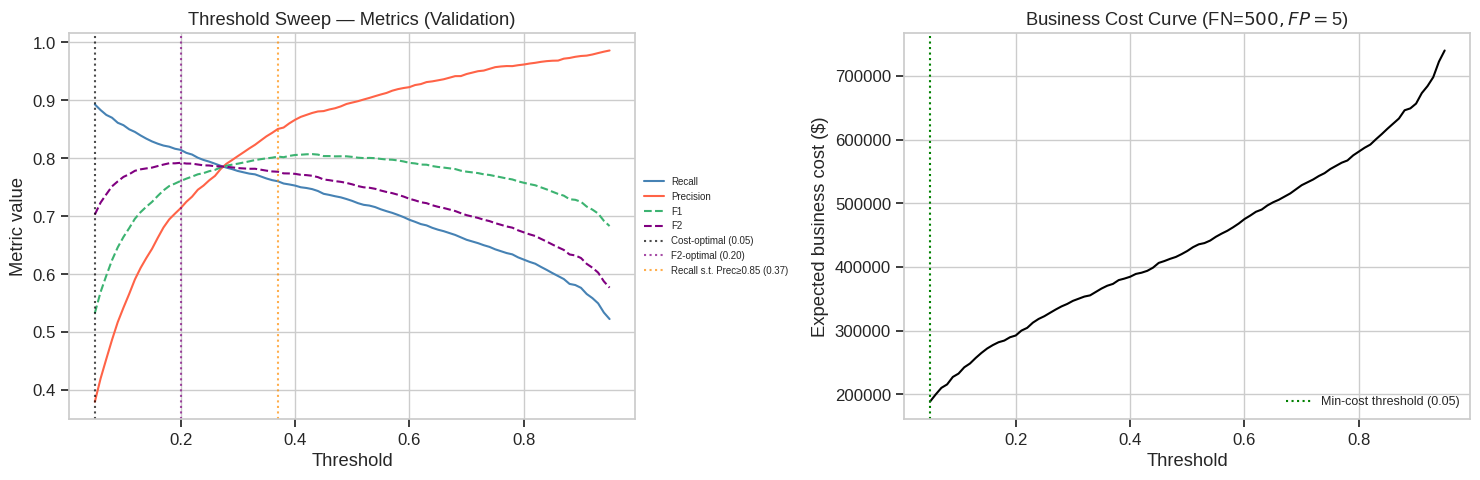

phase3_5_threshold_sweep.png saved ✓

✅ Using business-cost-optimal threshold as the default operating point: 0.05
   (swap FINAL_THRESHOLD to THRESH_F2 or THRESH_RECALL_CONSTRAINED for a different operating philosophy)


{'timestamp': '2026-07-10T05:23:31.283202',
 'phase': 'phase3.5',
 'experiment': 'phase3_5_threshold_optimization',
 'seed': 42,
 'config': '{"cost_fn": 500, "cost_fp": 5, "precision_floor": 0.85}',
 'timing_s': None,
 'memory_mb': None,
 'quality_metrics': '{}',
 'val_metrics': '{"threshold_cost_optimal": 0.05, "threshold_f2_optimal": 0.2, "threshold_recall_constrained": 0.37000000000000005}',
 'test_metrics': '{}',
 'notes': 'default production threshold = business_cost (0.05)'}

In [25]:

# ── Business cost assumptions (edit these for your actual cost structure) ────
COST_FALSE_NEGATIVE = 500   # cost of missing one fraudulent transaction ($)
COST_FALSE_POSITIVE = 5     # cost of wrongly flagging one legitimate transaction ($, friction/review cost)
PRECISION_FLOOR      = 0.85  # minimum acceptable precision for the recall-constrained search

THRESHOLD_GRID = np.arange(0.05, 0.951, 0.01)

def sweep_thresholds(y_true, y_prob, thresholds=THRESHOLD_GRID):
    rows = []
    for t in thresholds:
        pred = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
        rec  = tp / max(tp + fn, 1)
        prec = tp / max(tp + fp, 1)
        f1   = 2*prec*rec / max(prec+rec, 1e-9)
        f2   = 5*prec*rec / max(4*prec+rec, 1e-9)  # F-beta, beta=2
        cost = fn * COST_FALSE_NEGATIVE + fp * COST_FALSE_POSITIVE
        rows.append({'threshold': t, 'Recall': rec, 'Precision': prec, 'F1': f1, 'F2': f2,
                     'FP': fp, 'FN': fn, 'TP': tp, 'TN': tn, 'business_cost': cost})
    return pd.DataFrame(rows)

sweep_df = sweep_thresholds(y_val, sum(weight_map[n]*ensemble_members[n].predict_proba(X_val)[:,1]
                                        for n in member_names) if IS_ENSEMBLE_WINNER
                             else (xgb_tuned if 'XGBoost' in best_model_name else
                                   lgb_tuned if 'LightGBM' in best_model_name else
                                   xgb_tuned).predict_proba(X_val)[:, 1])

# ── 1. Business-cost-optimal threshold ────────────────────────────────────────
cost_optimal_row = sweep_df.loc[sweep_df['business_cost'].idxmin()]
THRESH_COST = cost_optimal_row['threshold']

# ── 2. F2-optimal threshold ────────────────────────────────────────────────────
f2_optimal_row = sweep_df.loc[sweep_df['F2'].idxmax()]
THRESH_F2 = f2_optimal_row['threshold']

# ── 3. Recall-maximizing subject to Precision >= floor ───────────────────────
feasible = sweep_df[sweep_df['Precision'] >= PRECISION_FLOOR]
if len(feasible) > 0:
    recall_constrained_row = feasible.loc[feasible['Recall'].idxmax()]
    THRESH_RECALL_CONSTRAINED = recall_constrained_row['threshold']
else:
    print(f'[WARN] No threshold achieves Precision >= {PRECISION_FLOOR}; using best available precision instead.')
    recall_constrained_row = sweep_df.loc[sweep_df['Precision'].idxmax()]
    THRESH_RECALL_CONSTRAINED = recall_constrained_row['threshold']

print('='*80)
print('THRESHOLD OPTIMIZATION — VALIDATION SET')
print('='*80)
print(f'\n[1] Business-cost-optimal  (FN=${COST_FALSE_NEGATIVE}, FP=${COST_FALSE_POSITIVE})')
print(f'    threshold={THRESH_COST:.2f}  cost=${cost_optimal_row["business_cost"]:,.0f}  '
      f'Recall={cost_optimal_row["Recall"]:.4f}  Precision={cost_optimal_row["Precision"]:.4f}')

print(f'\n[2] F2-optimal (recall weighted 2x over precision)')
print(f'    threshold={THRESH_F2:.2f}  F2={f2_optimal_row["F2"]:.4f}  '
      f'Recall={f2_optimal_row["Recall"]:.4f}  Precision={f2_optimal_row["Precision"]:.4f}')

print(f'\n[3] Recall-maximizing s.t. Precision >= {PRECISION_FLOOR}')
print(f'    threshold={THRESH_RECALL_CONSTRAINED:.2f}  Recall={recall_constrained_row["Recall"]:.4f}  '
      f'Precision={recall_constrained_row["Precision"]:.4f}')

# ── Visualize the sweep ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
ax.plot(sweep_df['threshold'], sweep_df['Recall'], label='Recall', color='steelblue')
ax.plot(sweep_df['threshold'], sweep_df['Precision'], label='Precision', color='tomato')
ax.plot(sweep_df['threshold'], sweep_df['F1'], label='F1', color='mediumseagreen', linestyle='--')
ax.plot(sweep_df['threshold'], sweep_df['F2'], label='F2', color='purple', linestyle='--')
for t, lbl, c in [(THRESH_COST, 'Cost-optimal', 'black'),
                  (THRESH_F2, 'F2-optimal', 'purple'),
                  (THRESH_RECALL_CONSTRAINED, f'Recall s.t. Prec≥{PRECISION_FLOOR}', 'darkorange')]:
    ax.axvline(t, linestyle=':', color=c, alpha=0.7, label=f'{lbl} ({t:.2f})')
ax.set_xlabel('Threshold'); ax.set_ylabel('Metric value')
ax.set_title('Threshold Sweep — Metrics (Validation)')
ax.legend(fontsize=7, loc='center left', bbox_to_anchor=(1.0, 0.5))

ax = axes[1]
ax.plot(sweep_df['threshold'], sweep_df['business_cost'], color='black')
ax.axvline(THRESH_COST, linestyle=':', color='green', label=f'Min-cost threshold ({THRESH_COST:.2f})')
ax.set_xlabel('Threshold'); ax.set_ylabel('Expected business cost ($)')
ax.set_title(f'Business Cost Curve (FN=${COST_FALSE_NEGATIVE}, FP=${COST_FALSE_POSITIVE})')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('phase3_5_threshold_sweep.png', dpi=140, bbox_inches='tight')
plt.show()
print('phase3_5_threshold_sweep.png saved ✓')

sweep_df.to_csv('phase3_5_threshold_sweep.csv', index=False)

# ── Default production threshold: business-cost-optimal ──────────────────────
FINAL_THRESHOLD = THRESH_COST
FINAL_THRESHOLD_STRATEGY = 'business_cost'
print(f'\n✅ Using business-cost-optimal threshold as the default operating point: {FINAL_THRESHOLD:.2f}')
print('   (swap FINAL_THRESHOLD to THRESH_F2 or THRESH_RECALL_CONSTRAINED for a different operating philosophy)')

log_experiment('phase3_5_threshold_optimization', phase='phase3.5',
               config={'cost_fn': COST_FALSE_NEGATIVE, 'cost_fp': COST_FALSE_POSITIVE,
                       'precision_floor': PRECISION_FLOOR},
               val_metrics={'threshold_cost_optimal': THRESH_COST, 'threshold_f2_optimal': THRESH_F2,
                            'threshold_recall_constrained': THRESH_RECALL_CONSTRAINED},
               notes=f'default production threshold = {FINAL_THRESHOLD_STRATEGY} ({FINAL_THRESHOLD:.2f})')


## 15. Final Test Set Evaluation (Business-Cost-Optimal Threshold)

In [26]:

test_pred = (test_prob >= FINAL_THRESHOLD).astype(int)

test_roc  = roc_auc_score(y_test, test_prob)
test_ap   = average_precision_score(y_test, test_prob)
test_f1   = f1_score(y_test, test_pred, zero_division=0)
test_rec  = recall_score(y_test, test_pred, zero_division=0)
test_prec = precision_score(y_test, test_pred, zero_division=0)
test_fpr  = confusion_matrix(y_test, test_pred)[0, 1] / max((y_test == 0).sum(), 1)
test_f2   = fbeta_score(y_test, test_pred, beta=2, zero_division=0)

print(f'{"="*60}')
print('FINAL TEST SET RESULTS')
print(f'{"="*60}')
print(f'Threshold ({FINAL_THRESHOLD_STRATEGY}) : {FINAL_THRESHOLD:.4f}')
print(f'ROC-AUC              : {test_roc:.4f}')
print(f'Average Precision    : {test_ap:.4f}')
print(f'Recall (Fraud)       : {test_rec:.4f}')
print(f'Precision            : {test_prec:.4f}')
print(f'F1 Score             : {test_f1:.4f}')
print(f'F2 Score             : {test_f2:.4f}')
print(f'False Positive Rate  : {test_fpr:.4f}')
print(f'{"="*60}')
print()
print(classification_report(y_test, test_pred, target_names=['Legitimate', 'Fraud']))

log_experiment('final_test_evaluation', phase='phase3.5',
               config={'threshold': FINAL_THRESHOLD, 'strategy': FINAL_THRESHOLD_STRATEGY},
               test_metrics={'ROC_AUC': test_roc, 'F1': test_f1, 'F2': test_f2,
                             'Recall': test_rec, 'Precision': test_prec, 'FPR': test_fpr})


FINAL TEST SET RESULTS
Threshold (business_cost) : 0.0500
ROC-AUC              : 0.9731
Average Precision    : 0.8627
Recall (Fraud)       : 0.8965
Precision            : 0.3803
F1 Score             : 0.5340
F2 Score             : 0.7050
False Positive Rate  : 0.0530

              precision    recall  f1-score   support

  Legitimate       1.00      0.95      0.97     85481
       Fraud       0.38      0.90      0.53      3100

    accuracy                           0.95     88581
   macro avg       0.69      0.92      0.75     88581
weighted avg       0.97      0.95      0.96     88581



{'timestamp': '2026-07-10T05:29:28.427892',
 'phase': 'phase3.5',
 'experiment': 'final_test_evaluation',
 'seed': 42,
 'config': '{"threshold": 0.05, "strategy": "business_cost"}',
 'timing_s': None,
 'memory_mb': None,
 'quality_metrics': '{}',
 'val_metrics': '{}',
 'test_metrics': '{"ROC_AUC": 0.9730728352763546, "F1": 0.5340122982321291, "F2": 0.7050436371016846, "Recall": 0.8964516129032258, "Precision": 0.38026819923371646, "FPR": 0.05298253413039155}',
 'notes': ''}

## 16. Final Visualisations

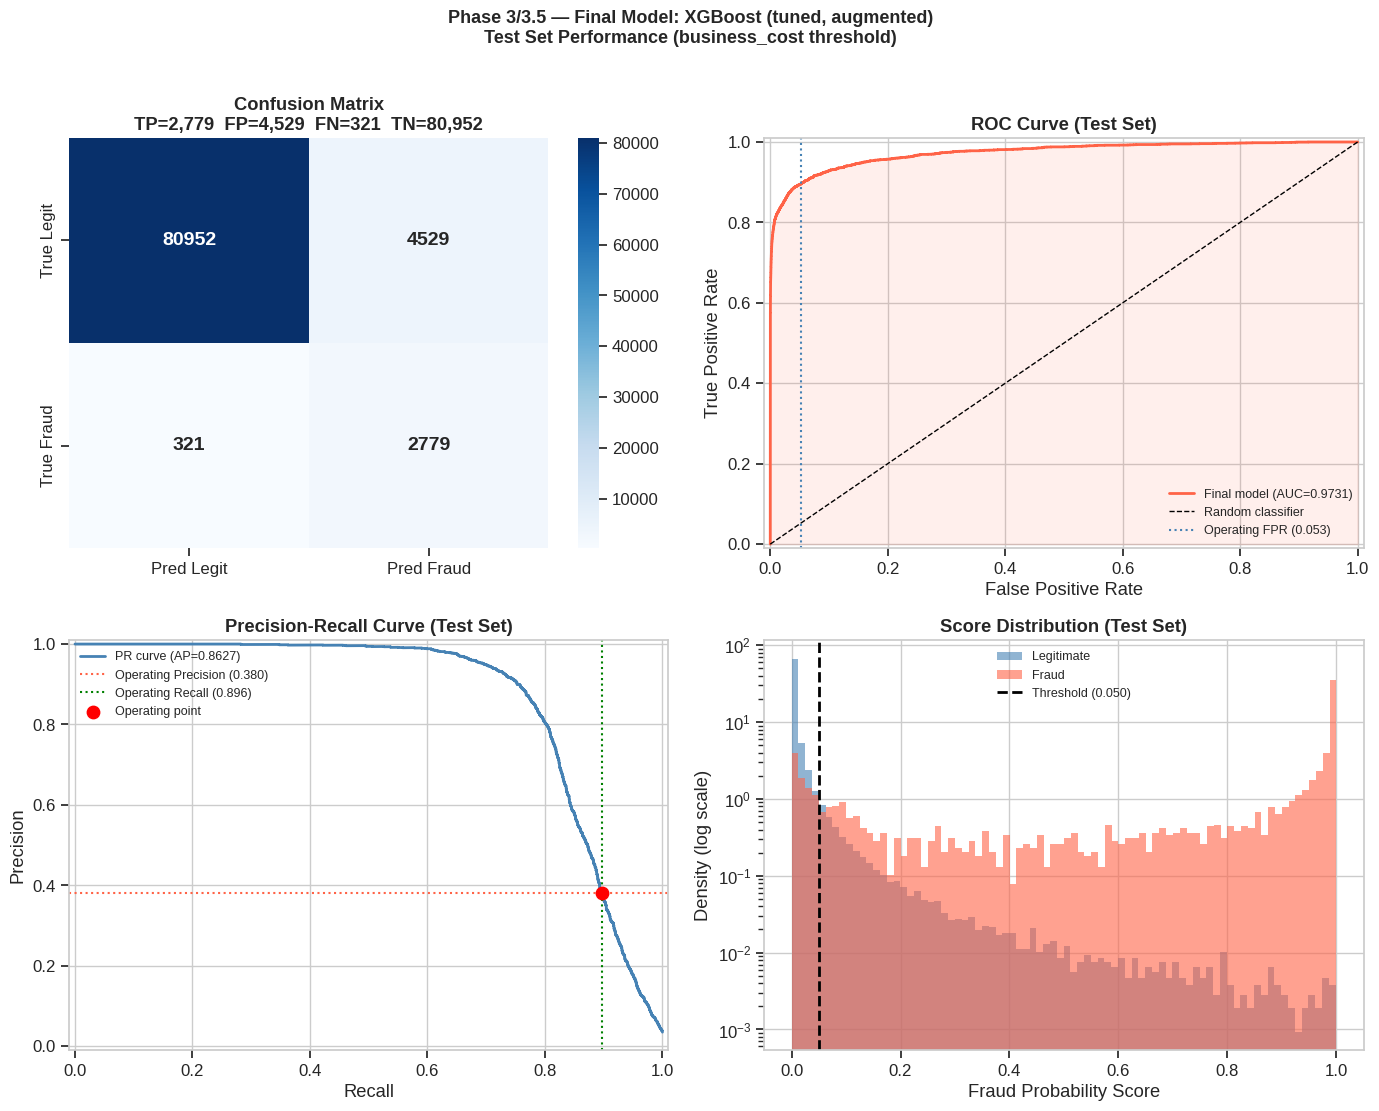

phase3_final_evaluation.png saved ✓


In [27]:

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

ax = axes[0, 0]
cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred Legit', 'Pred Fraud'], yticklabels=['True Legit', 'True Fraud'],
            annot_kws={'size': 14, 'weight': 'bold'})
tn, fp, fn, tp = cm.ravel()
ax.set_title(f'Confusion Matrix\nTP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}', fontweight='bold')

ax = axes[0, 1]
fpr_arr, tpr_arr, _ = roc_curve(y_test, test_prob)
ax.plot(fpr_arr, tpr_arr, lw=2, color='tomato', label=f'Final model (AUC={test_roc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.fill_between(fpr_arr, tpr_arr, alpha=0.1, color='tomato')
ax.axvline(test_fpr, color='steelblue', linestyle=':', lw=1.5, label=f'Operating FPR ({test_fpr:.3f})')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve (Test Set)', fontweight='bold')
ax.legend(fontsize=9); ax.set_xlim(-0.01, 1.01); ax.set_ylim(-0.01, 1.01)

ax = axes[1, 0]
prec_arr, rec_arr, thr_arr = precision_recall_curve(y_test, test_prob)
ax.plot(rec_arr, prec_arr, lw=2, color='steelblue', label=f'PR curve (AP={test_ap:.4f})')
ax.axhline(test_prec, color='tomato', linestyle=':', lw=1.5, label=f'Operating Precision ({test_prec:.3f})')
ax.axvline(test_rec,  color='green',  linestyle=':', lw=1.5, label=f'Operating Recall ({test_rec:.3f})')
ax.scatter([test_rec], [test_prec], color='red', zorder=5, s=80, label='Operating point')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve (Test Set)', fontweight='bold')
ax.legend(fontsize=9); ax.set_xlim(-0.01, 1.01); ax.set_ylim(-0.01, 1.01)

ax = axes[1, 1]
ax.hist(test_prob[y_test == 0], bins=80, alpha=0.6, color='steelblue', density=True, label='Legitimate', log=True)
ax.hist(test_prob[y_test == 1], bins=80, alpha=0.6, color='tomato', density=True, label='Fraud', log=True)
ax.axvline(FINAL_THRESHOLD, color='black', linestyle='--', lw=2, label=f'Threshold ({FINAL_THRESHOLD:.3f})')
ax.set_xlabel('Fraud Probability Score'); ax.set_ylabel('Density (log scale)')
ax.set_title('Score Distribution (Test Set)', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle(f'Phase 3/3.5 — Final Model: {best_model_name}\nTest Set Performance ({FINAL_THRESHOLD_STRATEGY} threshold)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('phase3_final_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('phase3_final_evaluation.png saved ✓')


## 17. Feature Importance

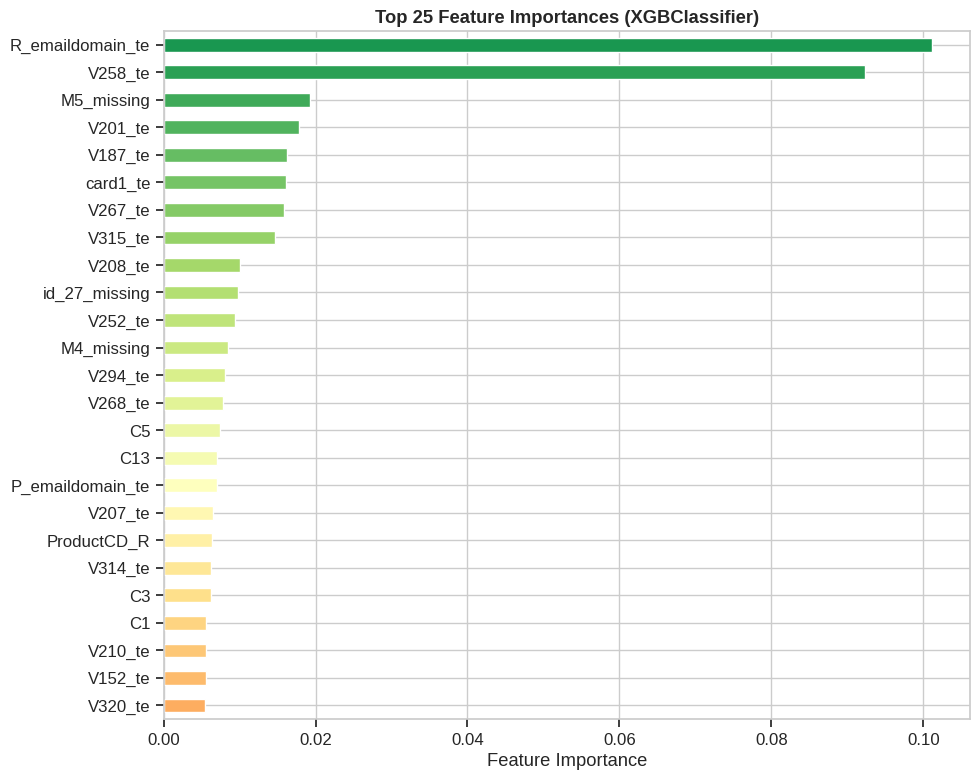

phase3_feature_importance.png saved ✓

Top 10 features:
   1. R_emaildomain_te                    0.101130
   2. V258_te                             0.092282
   3. M5_missing                          0.019211
   4. V201_te                             0.017812
   5. V187_te                             0.016200
   6. card1_te                            0.016109
   7. V267_te                             0.015848
   8. V315_te                             0.014667
   9. V208_te                             0.010002
  10. id_27_missing                       0.009761


In [28]:

importance_model = None
if IS_ENSEMBLE_WINNER:
    # Use the ensemble member with the highest tuned weight for feature-importance reporting
    top_member_name = max(weight_map, key=weight_map.get)
    importance_model = final_members[top_member_name]
    importance_label = f'{top_member_name} (top-weighted ensemble member)'
else:
    importance_model = final_model
    importance_label = type(final_model).__name__

if hasattr(importance_model, 'feature_importances_'):
    fi = pd.Series(importance_model.feature_importances_, index=FEATURE_COLS)
    fi = fi.sort_values(ascending=False).head(25)

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(fi)))[::-1]
    fi[::-1].plot.barh(ax=ax, color=colors[::-1], edgecolor='white')
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Top 25 Feature Importances ({importance_label})', fontweight='bold')
    plt.tight_layout()
    plt.savefig('phase3_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('phase3_feature_importance.png saved ✓')

    top_features = fi.index.tolist()
    print(f'\nTop 10 features:')
    for i, (feat, imp) in enumerate(fi.head(10).items(), 1):
        print(f'  {i:2d}. {feat:<35s} {imp:.6f}')
else:
    print('[INFO] Importance model does not expose feature_importances_ — skipping.')
    top_features = FEATURE_COLS[:10]
    fi = pd.Series(dtype=float)


## 18. Phase 1 → Phase 2 → Phase 3 → Phase 3.5 Improvement Summary

In [29]:

try:
    ph1_df = pd.read_csv('phase1_baseline_results.csv', index_col=0)
    ph1_best_f1     = ph1_df['F1'].max()
    ph1_best_recall = ph1_df['Recall_Fraud'].max()
    ph1_best_auc    = ph1_df['ROC_AUC'].max()
    ph1_available = True
    print('Phase 1 baseline results loaded ✓')
except Exception:
    ph1_best_f1 = ph1_best_recall = ph1_best_auc = None
    ph1_available = False
    print('[WARN] phase1_baseline_results.csv not found — using Phase 3 baseline as reference')

base_key = 'XGBoost_baseline' if 'XGBoost_baseline' in results_registry else list(results_registry.keys())[0]
p3_base = results_registry[base_key]

print(f'\n{"="*65}')
print('CROSS-PHASE IMPROVEMENT SUMMARY')
print(f'{"="*65}')
print(f'{"Metric":<20} {"Phase 1":>12} {"Phase 3 Base":>14} {"Phase 3.5 Final":>16} {"Improvement":>12}')
print('-' * 78)

for metric, ph1_val, base_val, final_val in [
    ('ROC-AUC',       ph1_best_auc    if ph1_available else p3_base['ROC_AUC'], p3_base['ROC_AUC'],   test_roc),
    ('Recall (Fraud)',ph1_best_recall if ph1_available else p3_base['Recall'],  p3_base['Recall'],    test_rec),
    ('F1 Score',      ph1_best_f1     if ph1_available else p3_base['F1'],      p3_base['F1'],        test_f1),
    ('Precision',     None,                                                     p3_base['Precision'], test_prec),
]:
    ph1_str   = f'{ph1_val:.4f}' if ph1_val is not None else '  N/A  '
    delta     = final_val - base_val
    delta_str = f'{delta:+.4f}'
    print(f'{metric:<20} {ph1_str:>12} {base_val:>14.4f} {final_val:>16.4f} {delta_str:>12}')

print(f'{"="*65}')

print('\n=== FINAL SUCCESS CRITERIA CHECK ===')
criteria = [
    ('Recall ≥ 0.85',  test_rec  >= 0.85),
    ('Precision ≥ 0.90', test_prec >= 0.90),
    ('F1 ≥ 0.87',      test_f1   >= 0.87),
    ('ROC-AUC ≥ 0.95', test_roc  >= 0.95),
    ('+5% recall vs baseline', (test_rec - p3_base['Recall']) >= 0.05),
]
all_pass = True
for label, passed in criteria:
    icon = '✅' if passed else '❌'
    print(f'  {icon} {label}')
    if not passed:
        all_pass = False

if all_pass:
    print('\n🎉 ALL CRITERIA MET — Phase 3/3.5 complete!')
else:
    print('\n⚠️  Some criteria not yet met — consider: more Optuna trials, different ensemble weights, or a looser precision floor.')

log_experiment('cross_phase_summary', phase='phase3.5',
               test_metrics={'test_roc_auc': test_roc, 'test_f1': test_f1, 'test_recall': test_rec,
                             'test_precision': test_prec, 'all_criteria_pass': all_pass})


[WARN] phase1_baseline_results.csv not found — using Phase 3 baseline as reference

CROSS-PHASE IMPROVEMENT SUMMARY
Metric                    Phase 1   Phase 3 Base  Phase 3.5 Final  Improvement
------------------------------------------------------------------------------
ROC-AUC                    0.9504         0.9504           0.9731      +0.0227
Recall (Fraud)             0.6257         0.6257           0.8965      +0.2708
F1 Score                   0.6853         0.6853           0.5340      -0.1513
Precision                   N/A           0.7574           0.3803      -0.3771

=== FINAL SUCCESS CRITERIA CHECK ===
  ✅ Recall ≥ 0.85
  ❌ Precision ≥ 0.90
  ❌ F1 ≥ 0.87
  ✅ ROC-AUC ≥ 0.95
  ✅ +5% recall vs baseline

⚠️  Some criteria not yet met — consider: more Optuna trials, different ensemble weights, or a looser precision floor.


{'timestamp': '2026-07-10T05:29:31.529893',
 'phase': 'phase3.5',
 'experiment': 'cross_phase_summary',
 'seed': 42,
 'config': '{}',
 'timing_s': None,
 'memory_mb': None,
 'quality_metrics': '{}',
 'val_metrics': '{}',
 'test_metrics': '{"test_roc_auc": 0.9730728352763546, "test_f1": 0.5340122982321291, "test_recall": 0.8964516129032258, "test_precision": 0.38026819923371646, "all_criteria_pass": false}',
 'notes': ''}

## 19. Save All Phase 3 / 3.5 Outputs

In [30]:

# ── Final model(s) ─────────────────────────────────────────────────────────────
if IS_ENSEMBLE_WINNER:
    joblib.dump({'members': final_members, 'weights': weight_map}, 'fraud_classifier_phase3.pkl')
    print('fraud_classifier_phase3.pkl saved (ensemble dict: members + weights) ✓')
else:
    joblib.dump(final_model, 'fraud_classifier_phase3.pkl')
    print('fraud_classifier_phase3.pkl saved ✓')

if calibrated_models:
    joblib.dump(calibrated_models, 'fraud_classifier_calibrated_models.pkl')
    print('fraud_classifier_calibrated_models.pkl saved ✓')

# ── Threshold + metadata ──────────────────────────────────────────────────────
threshold_meta = {
    'threshold':          FINAL_THRESHOLD,
    'threshold_strategy': FINAL_THRESHOLD_STRATEGY,
    'threshold_cost_optimal': THRESH_COST,
    'threshold_f2_optimal':   THRESH_F2,
    'threshold_recall_constrained': THRESH_RECALL_CONSTRAINED,
    'best_model_name':    best_model_name,
    'is_ensemble':        IS_ENSEMBLE_WINNER,
    'ensemble_weights':   weight_map if IS_ENSEMBLE_WINNER else None,
    'val_f1':             best_row['F1'],
    'val_recall':         best_row['Recall'],
    'val_precision':      best_row['Precision'],
    'val_roc_auc':        best_row['ROC_AUC'],
    'test_f1':            test_f1,
    'test_f2':            test_f2,
    'test_recall':        test_rec,
    'test_precision':     test_prec,
    'test_roc_auc':       test_roc,
    'feature_cols':       FEATURE_COLS,
    'cost_false_negative': COST_FALSE_NEGATIVE,
    'cost_false_positive': COST_FALSE_POSITIVE,
    'precision_floor':     PRECISION_FLOOR,
}
joblib.dump(threshold_meta, 'fraud_classifier_threshold_meta.pkl')
print('fraud_classifier_threshold_meta.pkl saved ✓')

# ── Results CSVs ───────────────────────────────────────────────────────────────
full_df.to_csv('phase3_all_models_results.csv', index=False)
cv_df.to_csv('phase3_cv_results.csv')
sweep_df.to_csv('phase3_5_threshold_sweep.csv', index=False)
xgb_study.trials_dataframe().to_csv('phase3_xgb_optuna_trials.csv', index=False)
lgb_study.trials_dataframe().to_csv('phase3_lgb_optuna_trials.csv', index=False)
if CATBOOST_OK and cat_study is not None:
    cat_study.trials_dataframe().to_csv('phase3_cat_optuna_trials.csv', index=False)
print('Results CSVs saved ✓')

# ── Feature importance ─────────────────────────────────────────────────────────
if not fi.empty:
    fi_df = pd.DataFrame({'Feature': fi.index, 'Importance': fi.values}).sort_values('Importance', ascending=False)
    fi_df.to_csv('phase3_feature_importance.csv', index=False)
    print('phase3_feature_importance.csv saved ✓')

# ── Test predictions (for Phase 4 SHAP + ablation studies) ───────────────────
test_preds_df = pd.DataFrame({
    'y_true':      y_test,
    'y_prob':      test_prob,
    'y_pred':      test_pred,
    'correct':     (y_test == test_pred).astype(int),
    'fraud_missed': ((y_test == 1) & (test_pred == 0)).astype(int),
    'false_alarm':  ((y_test == 0) & (test_pred == 1)).astype(int),
})
test_features_df = pd.DataFrame(X_test, columns=FEATURE_COLS)
test_output_df = pd.concat([test_preds_df, test_features_df], axis=1)
test_output_df.to_csv('phase3_test_predictions.csv', index=False)
print('phase3_test_predictions.csv saved ✓')

print()
print('='*60)
print('Phase 3 + 3.5 complete! Files ready for Phase 4 (SHAP + ablation studies):')
print('  fraud_classifier_phase3.pkl              → model (or ensemble dict)')
print('  fraud_classifier_calibrated_models.pkl    → Platt/Isotonic-calibrated variants')
print('  fraud_classifier_threshold_meta.pkl       → all 3 threshold strategies + metadata')
print('  phase3_test_predictions.csv               → test predictions with features')
print('  phase3_feature_importance.csv             → ranked feature importances')
print('  phase3_all_models_results.csv             → full leaderboard')
print('  phase3_5_threshold_sweep.csv              → full 0.05-0.95 threshold sweep')
print('  experiment_log.csv                        → cumulative experiment log (Phases 1-3.5)')
print('='*60)


fraud_classifier_phase3.pkl saved ✓
fraud_classifier_calibrated_models.pkl saved ✓
fraud_classifier_threshold_meta.pkl saved ✓
Results CSVs saved ✓
phase3_feature_importance.csv saved ✓
phase3_test_predictions.csv saved ✓

Phase 3 + 3.5 complete! Files ready for Phase 4 (SHAP + ablation studies):
  fraud_classifier_phase3.pkl              → model (or ensemble dict)
  fraud_classifier_calibrated_models.pkl    → Platt/Isotonic-calibrated variants
  fraud_classifier_threshold_meta.pkl       → all 3 threshold strategies + metadata
  phase3_test_predictions.csv               → test predictions with features
  phase3_feature_importance.csv             → ranked feature importances
  phase3_all_models_results.csv             → full leaderboard
  phase3_5_threshold_sweep.csv              → full 0.05-0.95 threshold sweep
  experiment_log.csv                        → cumulative experiment log (Phases 1-3.5)
